<h1 style="text-align: center; font-family: Arial; font-weight: bold; color:green; font-size:36px;">Indigenous Energy Forecasting
    for the Republic of Ireland</h1>

<b>Author:</b> J.A Montuya<br />
<b>Student ID:</b> 2025040<br />
<h3>Abstract:</h3>
    This study aims to develop a reliable forecasting model for predicting renewable energy outputs in the Republic of Ireland, utilizing various supervised machine learning algorithms. All datasets utilised in this research were validated to ensure adherence to data usage policy, avoiding potential legal actions for misuse.  In addition, energy-related discussions were gathered using the Reddit API to analyze sentiments, which were compared against those of other European countries using the Flair sentiment model and other text processing methodologies to generate insights. Algorithms, such as Artificial Neural Networks (ANN), Seasonal Autoregressive Integrated Moving Average (SARIMA), and Tree-based models–specifically Random Forest and Extreme Gradient Boosting (XGBoost) were implemented and analyzed to find the best model suited for the study. The resulting forecasting model can assist in creating data-driven decisions and planning to improve energy infrastructure and development across Ireland.

### Import Libraries

In [4]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Time Series Analysis
from statsmodels.tsa.seasonal import seasonal_decompose

# Scaler and Score Metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.metrics import RootMeanSquaredError


# Statistics
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy.stats import shapiro, kruskal, pearsonr, spearmanr, kruskal, mannwhitneyu, ttest_ind
from statsmodels.stats.diagnostic import linear_reset, acorr_breusch_godfrey
from scipy import stats

# Tree-based Algorithms
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Neural Network
from keras.models import Sequential
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout, Input
from keras.metrics import RootMeanSquaredError, MeanAbsoluteError
import tensorflow as tf

# SARIMA
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pickle

# Set Random Values
import random

# Get time
import time


In [5]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Install required packages
#pip install pmdarima
#!pip install scikeras

### Custom Functions

In [8]:
def generate_pie_chart(data, start, end, columns, title): 
    
    # Filter data by year, providing start and end year
    filtered_data = ie_power_production_df.loc[(ie_power_production_df.Year > start) & (ie_power_production_df.Year<end)]
    
    # Group by Year
    yearly_data = filtered_data.groupby('Year')[columns].sum().reset_index()

    # Add the total renewable energy production for each year
    yearly_data['Total'] = yearly_data[columns].sum(axis=1)
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=len(yearly_data),
        specs=[[{'type':'domain'}]*len(yearly_data)],
        subplot_titles=[str(year) for year in yearly_data['Year']]
    )
    
    # Loop by yearly data
    for idx, row in yearly_data.iterrows():
        fig.add_trace(
            go.Pie(
                labels=columns,  # use correct column labels
                values=[row[col] for col in columns],  # pick values for that row
                name=str(row['Year']),
                hole=0.4,
                textinfo='label+percent',  
                hoverinfo='label+percent+value',  
                title=f"Total: {row['Total']:.2f} ktoe"
            ),
            row=1, 
            col=idx+1  # index is 0-based, subplot cols start at 1
        )
    # Update Titles 
    fig.update_layout(title_text=title, height=500)

    #Render Graph
    fig.show()

def decompose(data):
    # Decompose data
    result = seasonal_decompose(data, model='additive')
    
    # Create subplots
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
    
    # Plot Observed 
    sns.lineplot(
        x=result.observed.index, 
        y=result.observed.values, 
        ax=axes[0],
        color='navy'
    )
    axes[0].set_title('Observed', loc='left')
    
    # Plot Trend
    sns.lineplot(
        x=result.trend.index, 
        y=result.trend.values, 
        ax=axes[1],
        color='green'
    )
    axes[1].set_title('Trend', loc='left')
    
    # Plot Seasonal
    sns.lineplot(
        x=result.seasonal.index, 
        y=result.seasonal.values, 
        ax=axes[2],
        color='orange'
    )
    axes[2].set_title('Seasonality', loc='left')
    
    # Plot Residuals
    sns.scatterplot(
        x=result.resid.index, 
        y=result.resid.values, 
        ax=axes[3],
        color='crimson',
        s=30  # Size of dots
    )
    axes[3].set_title('Residuals', loc='left')
    
    plt.tight_layout()
    plt.show()

# Create a function to return rows containing outliers using IQR
def check_outliers(data, feature_name):
    # Calculate the 25th and 75th percentiles
    Q1 = np.percentile(data[feature_name], 25)
    Q3 = np.percentile(data[feature_name], 75)
    # Calculate for IQR 
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 
    
    # Return records where the feature value is below the lower bound or above the upper bound
    outliers = data.loc[(data[feature_name] < lower_bound) | (data[feature_name] > upper_bound)]
    return outliers

def transform_right_skewed(data):
    #Create a variable to store the results of the testing
    transformation_df = pd.DataFrame()
    
    # Apply transformations
    transformation_df['original']=data
    transformation_df['log'] = np.log(data + 1)  # Avoid log(0)
    transformation_df['square'] = np.square(data)
    transformation_df['cbrt'] = np.cbrt(data)
    
    # Create 2 x 2 subplots 
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    
    # Log Transformation
    sns.histplot(data=transformation_df, x='original', kde=True, bins=10, ax=axes[0, 0], color='green')
    axes[0, 0].set_title('Original')
    
    # Log Transformation
    sns.histplot(data=transformation_df, x='log', kde=True, bins=10, ax=axes[0, 1], color='green')
    axes[0, 1].set_title('Distribution Plot: Log Transform')
    
    # Square Transformation
    sns.histplot(data=transformation_df, x='square', kde=True, bins=10, ax=axes[1, 0], color='green')
    axes[1, 0].set_title('Distribution Plot: Square')
    
    # Cube Root Transformation
    sns.histplot(data=transformation_df, x='cbrt', kde=True, bins=10, ax=axes[1, 1], color='green')
    axes[1, 1].set_title('Distribution Plot: Cube Root')

    plt.tight_layout()
    plt.show()

    # Return values
    return transformation_df


# Add Engineered Features to the dataframe
def add_features(dataframe):
   seasons = {
    'winter':[12, 1, 2],
    'spring':[3, 4, 5],
    'summer':[6, 7, 8],
    'autumn':[9,10,11],
    'start_month':[1],
    'end_month':[12]  
   }
    
   for seasons, months in seasons.items():
        dataframe[seasons] = dataframe['Month_Numeric'].isin(months).astype(int)
       
   return dataframe

# Create lag features
def generate_lag_features(data, n_lags):
    lags_df = pd.DataFrame(data)
    for lag in range(1, n_lags + 1):
        lags_df[f'lag_{lag}'] = data.shift(lag)
    lags_df.dropna(inplace=True)
    return lags_df

# Plot Measure of Central Tendency, variance, and standard deviation
# data - dataframe feature
# title - title of the graph
def plot_central_tendency(df, column, ax):
    data = df[column]

    # Calculate for mean, median, mode, std, and variance
    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode().iloc[0]
    variance = np.var(data,  ddof=1)
    std = np.std(data)  

    # Plot histogram
    sns.histplot(data=df, x=column, kde=True, color='green', bins=20, ax=ax)

    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    ax.axvline(mode_val, color='purple', linestyle='--', label=f'Mode: {mode_val:.2f}')

    ax.set_title(f' Measure of Central Tendency of {column},\n Variance:{variance:.2f}, Standard Deviation: {std:.2f}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    ax.legend()


# Simplify Exporting of Graphs
def export_graph(filename='img', graph_type='plt'):
    try:
        if graph_type == 'fig':
            fig.write_image(f"./assets/{filename}.png")
        else:
            plt.savefig(f"./assets/{filename}.png", dpi=300, bbox_inches='tight')
        print('Graph exported.')
    except:
        print('There is a error exporting the graph.')


# Check dataframe file size
def check_dataframe_filesize(data):
    size_kb = data.memory_usage(deep=True).sum() / 1024
    return size_kb


total_freed_memory_kb=[]
# Delete a dataframe and check total freed memory
def delete_df(df_name):
    # Find the dataframe in global variables
    if df_name in globals():
        if isinstance(globals()[df_name], pd.DataFrame):
            file_size=check_dataframe_filesize(globals()[df_name])
            del globals()[df_name]
            total_freed_memory_kb.append(file_size)
            print(f'Total freed memory:{sum(total_freed_memory_kb)}kb.')
        else:
            print('Dataframe name does not exist.')
    else:
        print('Dataframe name does not exist.')

# Processing Runtime
class GetRuntime:
    def __init__(self):
        self.start_time = None
        self.end_time= None
        self.runtime = None

    def start(self):
            self.start_time = time.time()

    def stop(self):
            self.end_time = time.time()
            print(f'Runtime: {self.end_time - self.start_time:.3f} seconds.')
    def get_results(self):
            return float(self.end_time - self.start_time)

# Set timer
timer=GetRuntime()

# Simplify Dropping of features
def drop_features(dataframe, features):
    try:
        dataframe.drop(columns=features, inplace=True)
    except:
        print('Error in dropping columns. No changes made.')
    
    return dataframe

## Load Dataset

<b> Dataset:</b>  Indigenous Energy Production in the Republic of Ireland <br />
<b> Source:</b> SEAI <br />
<b> Description:</b> This dataset provides monthly energy output of indigenous energy sources in Ireland. It highlights the contribution of locally produced energy to the national grid.
<br />

    Features:
    1.	Year of Period – The year of the energy production record. 
    2.	Month of Period – The specific month the data was collected.
    3.	Unit – The measurement unit used in ktoe (kilotonnes of oil equivalent).
    4.	Coal – Energy produced from coal combustion.
    5.	Combust. Renew. – Renewable energy generated from combustible sources (e.g., biomass).
    6.	Hydro – Energy production from hydroelectric sources.
    7.	Natural Gas – Energy from domestically produced natural gas.
    8.	Oil – Indigenous oil-based energy output.
    9.	Other – Any other minor or unclassified energy sources.
    10.	Peat & BM – Peat and biogenic materials (BM) used for energy production.
    11.	Solar Farms – Electricity generated by solar photovoltaic farms.
    12.	Wastes – Energy recovered from waste-to-energy processes.
    13.	Wind – Wind-generated energy.

In [10]:
# Import Dataset
ie_power_production_df = pd.read_csv('./Datasets/AA.csv',)

# Show first 5 records
ie_power_production_df=ie_power_production_df.loc[ie_power_production_df['Year of Period']<2025]
ie_power_production_df.head()

,Year of Period,Month of Period,Unit,Coal,Combust. Renew.,Hydro,Natural Gas,Oil,Other,Peat & BM,Solar Farms,Wastes,Wind
1,2024,January,ktoe,8.6,1.1,11.3,113.8,2.4,0.1,3.4,1.5,4.8,98.2
2,2024,February,ktoe,7.4,1.0,9.8,85.3,1.0,0.1,4.6,1.7,4.3,103.0
3,2024,March,ktoe,7.5,1.2,10.0,87.7,0.5,0.1,4.2,3.0,1.9,114.4
4,2024,April,ktoe,7.1,1.1,7.6,92.2,0.4,0.1,4.4,5.6,3.3,79.9
5,2024,May,ktoe,2.1,1.1,3.0,116.1,2.1,0.1,5.1,8.1,4.8,48.2


## <h2 style="text-align: center; font-family: Arial; font-weight:bold">1. Data Preparation & Visualisation</h1>
<br />

## 1.1 Data Preparation
Checks for data inconsistencies were done before training to mitigate issues before model training. <br /><br />

By checking the information, the dataframe consists of 180 records and 13 features. All numerical features are of type int or float, indicating that there are no invalid values (eg., 'na', 'n/a') in the data.


In [13]:
ie_power_production_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 1 to 180
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year of Period   180 non-null    int64  
 1   Month of Period  180 non-null    object 
 2   Unit             180 non-null    object 
 3   Coal             180 non-null    float64
 4   Combust. Renew.  180 non-null    float64
 5   Hydro            180 non-null    float64
 6   Natural Gas      180 non-null    float64
 7   Oil              180 non-null    float64
 8   Other            180 non-null    float64
 9   Peat & BM        180 non-null    float64
 10  Solar Farms      180 non-null    float64
 11  Wastes           180 non-null    float64
 12  Wind             180 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 19.7+ KB


### 1.1.1 Null and Duplicates Check

Null and duplicates are common issues of the datasets, and failing to remove these discrepancies might produce errors in training or contribute to the low performance of the model.

In [15]:
# Check for duplicates
print(f'There are {ie_power_production_df.duplicated().sum()} duplicated values in the dataset.')

There are 0 duplicated values in the dataset.


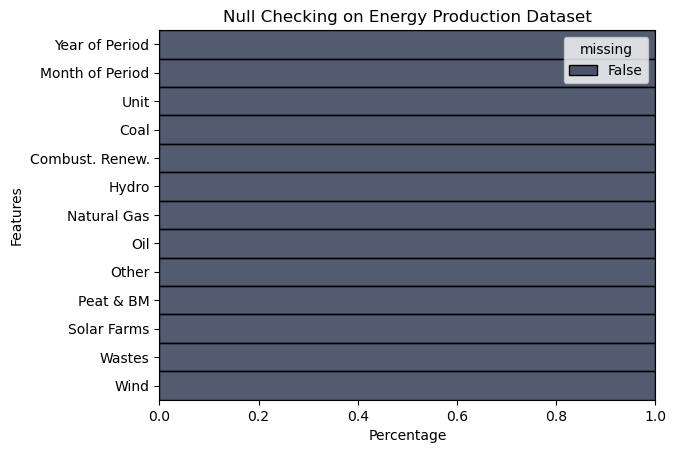

In [16]:
# Set figure pallete
sns.set_palette('cubehelix')

# Plot missing values
sns.histplot(
    data = ie_power_production_df.isnull().melt(value_name='missing'),
    y='variable',
    hue='missing',
    multiple = 'fill'
)

# Display result
plt.title('Null Checking on Energy Production Dataset')
plt.xlabel('Percentage')
plt.ylabel('Features')

# Save figure
# plt.savefig("./assests/null_checking.png", dpi=300, bbox_inches='tight')

plt.show()

    Based on the result shown above, there were no missing values in the dataset.

#### Check for Number of Unique Values

This process helps determine whether a feature is categorical or continuous and can detect potential issues (e.g., if months has 13 values). For this dataframe, the unit has only 1 unique value (ktoe), thus, we can remove this column since this is irrelevant to the analysis.

In [19]:
# Checking for unique values
ie_power_production_df.nunique()

Year of Period      15
Month of Period     12
Unit                 1
Coal               135
Combust. Renew.     10
Hydro               92
Natural Gas        158
Oil                 47
Other               15
Peat & BM          103
Solar Farms         23
Wastes              34
Wind               162
dtype: int64

#### Renaming Columns

Renaming columns helps in readability by reducing the length (e.g., 'Year of Period':'Year'), which also makes data accessibility easier.

In [21]:
ie_power_production_df.rename(columns={
    'Year of Period':'Year',
    'Month of Period':'Month',
    'Natural Gas': 'Natural_Gas',
    'Peat & BM': 'Peat_&_BM',
    'Solar Farms': 'Solar_Farms',
    'Combust. Renew.': 'Combustibles'
}, inplace=True)

#### Dropping Irrelevant Features

Removing irrelevant comments can help curate data for analysis; it saves memory, storage, and helps speed up the model training process. Thus, for this dataset, the 'unit' feature was dropped since it has only 1 unique value(ktoe). <br /><br />

A try-except block was implemented to prevent errors when attempting to drop columns that may have already been removed from the previous code execution.

In [23]:
# Drop features using a custom function with built-in error handling
ie_power_production_df=drop_features(ie_power_production_df, features=['Unit'])

# Check the dataframe 
ie_power_production_df.head()

,Year,Month,Coal,Combustibles,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind
1,2024,January,8.6,1.1,11.3,113.8,2.4,0.1,3.4,1.5,4.8,98.2
2,2024,February,7.4,1.0,9.8,85.3,1.0,0.1,4.6,1.7,4.3,103.0
3,2024,March,7.5,1.2,10.0,87.7,0.5,0.1,4.2,3.0,1.9,114.4
4,2024,April,7.1,1.1,7.6,92.2,0.4,0.1,4.4,5.6,3.3,79.9
5,2024,May,2.1,1.1,3.0,116.1,2.1,0.1,5.1,8.1,4.8,48.2


### 1.1.1 Feature Engineering

Methods such as converting string months to numerical values, and an additional feature 'date' in 'YYYY-mm-dd' format to be set as index as required for ARIMA model.

In [25]:
# Transform Months to Numeric
ie_power_production_df['Month_Numeric'] =  pd.to_datetime(ie_power_production_df['Month'], format='%B').dt.month

# Transform Year and Month to Date
ie_power_production_df['Date'] = pd.to_datetime(ie_power_production_df['Year'].astype(str) + '-' + ie_power_production_df['Month_Numeric'].astype(str).str.zfill(2) + '-01')

# Set Date as Index
ie_power_production_df.set_index('Date', inplace=True)

#### Sum Renewable and Non-renewable Sources

Since the analysis requires data for both renewable and non-renewable energy sources, new features can be engineered by summing the relevant classified columns. These new columns will be utilized for prediction.

In [27]:
# Classify Features to Renewable and Non-Renewable Sources
renewable_energy = ['Hydro', 'Solar_Farms', 'Wastes', 'Wind']
nonrenewable_energy = ['Coal', 'Natural_Gas', 'Oil', 'Peat_&_BM', 'Other']

# Sum all renewable energy sources
ie_power_production_df['Renewable_Energy'] = ie_power_production_df[renewable_energy].sum(axis=1)

# Sum all non-renewable energy sources
ie_power_production_df['Non_Renewable_Energy'] = ie_power_production_df[nonrenewable_energy].sum(axis=1)

# Sort Date in ascending order
ie_power_production_df.sort_index(inplace=True)

# Check dataset if changes have been made 
ie_power_production_df.head()

,Year,Month,Coal,Combustibles,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind,Month_Numeric,Renewable_Energy,Non_Renewable_Energy
Date,,,,,,,,,,,,,,,
2010-01-01,2010,January,34.4,0.0,8.3,126.8,6.7,1.7,16.7,0.0,0.0,21.3,1,29.6,186.3
2010-02-01,2010,February,35.0,0.0,5.1,120.0,2.5,1.9,16.3,0.0,0.0,13.0,2,18.1,175.7
2010-03-01,2010,March,26.5,0.0,2.5,136.8,1.4,1.9,14.8,0.0,0.0,21.6,3,24.1,181.4
2010-04-01,2010,April,20.0,0.0,6.3,117.6,1.2,2.0,18.3,0.0,0.0,16.0,4,22.3,159.1
2010-05-01,2010,May,23.3,0.0,1.1,116.4,0.6,1.6,15.2,0.0,0.0,14.5,5,15.6,157.1


## 1.2 Data Visualisation

The pie charts below illustrate the distribution of renewable and non-renewable energy production sources in Ireland for the past three years (2022-2024). The charts present the percentage contribution and total energy produced each year. This information helps identify the dominant sources of energy production, which may assist grid distributors and energy stakeholders in making strategic decisions regarding resource allocation, infrastructure investment, and future energy planning. 

In [29]:
generate_pie_chart(ie_power_production_df, 2021, 2025, renewable_energy, 'Renewable Energy Production Sources for the Past 3 Years')

        The charts show that wind energy is the dominant source of renewable energy, having above 80% contribution for the last 3 years. There is also an observable growth in solar farms from a contribution of 0.101% in 2022 to 5.26% in 2024. There is a reduced output of energy produced by waste. The gross renewable energy generated is above 1000 ktoe for the past 3 years. 

In [31]:
generate_pie_chart(ie_power_production_df, 2021, 2025, nonrenewable_energy, 'Non-Renewable Energy Production Sources for the Past 3 Years')

        The natural gas governs non-renewable energy production, which contributes above 80 percent or more than 1,200 ktoe annually. However, the total output of energy sources declined from 1656 ktoe to 1345 ktoe from 2022 to 2024, which is approximately 18% in energy output. This trend indicates efforts from the government to reduce dependency on fossil fuels to transition to greener energy.

#### Percentage Chart to Compare Renewable and Non-renewable Energy

The stacked bar chart illustrates the proportion of renewable and non-renewable energy from the year 2010 to 2025. This highlights the notable transition to greener energy sources over time, with renewable energy producing over 50% of the power from the start of the 2020s, as also confirmed by the previous plot. There is also an observable fluctuation in the first and last quarters of the year, suggesting that seasonal weather patterns affect energy output.

In [34]:
# Convert values to percentages by row
by_energy_group = ie_power_production_df[['Renewable_Energy', 'Non_Renewable_Energy']].copy()
by_energy_group = by_energy_group.div(by_energy_group.sum(axis=1), axis=0) * 100

fig = go.Figure()

# Define custom colors
color_map = {
    'Renewable_Energy': 'green',
    'Non_Renewable_Energy': 'lightblue'
}

for source in by_energy_group:
    fig.add_trace(go.Bar(
        x=by_energy_group.index.astype(str),  
        y=by_energy_group[source],              
        name=source,
        marker_color = color_map[source]
    ))

fig.update_layout(
    barmode='stack',
    bargap=0.001,  
    yaxis=dict(title='Percentage', range=[0, 100]),
    title_text='% Chart - Comparing Renewable and Non-Renewable Energy Over Time',
    legend=dict(
        x=0.75,
        y=1.2,
        xanchor='left', 
        yanchor='top'
    ),
    height=500,
    width=1100
)

fig.update_traces(marker_line_width=0)

fig.show()

#Free up memory
delete_df('by_energy_group')

Total freed memory:4.21875kb.


#### Faceted Bar Chart on Wind Production

To analyze the monthly contribution of wind energy production over the past three years (2022–2024), the chart confirms our earlier observations: output tends to peak during the first and last quarters of each year and dip during the summer months, indicating seasonality. This insight enables grid operators to make informed decisions on when to shift energy sources during periods of low wind output.

In [36]:
start_year=2021
end_year=2025
filtered_data=ie_power_production_df.loc[(ie_power_production_df.Year>start_year) & (ie_power_production_df.Year<end_year)]

fig = px.bar(
    filtered_data,
    x='Month',   
    y='Wind',             
    color='Year',         
    barmode='group',      
    facet_col='Year',  
    labels={
        'Month_Numeric':'Month',
        'Wind':'Wind Energy (ktoe)'
    },
    title='Monthly Wind Energy Production by Year',
)

fig.show()

# Free up memory
delete_df('filtered_data')

Total freed memory:10.236328125kb.


## 1.3 Exploratory Data Analysis

### 1.3.1 Outlier Checking and Handling

Outlier checking was also performed to avoid a negative impact on accuracy if not handled effectively, resulting in over- or under-fitting and biased results. Boxplots indicate that the non-renewable energy feature contains outliers. 

In [39]:
# Plot boxplot to identify outliers
fig = px.box(ie_power_production_df[['Renewable_Energy', 'Non_Renewable_Energy']])

# Set graph size and update y-axis title
fig.update_layout(height=600, 
                  width=600, 
                  yaxis_title='Energy Production (ktoe)')
# Show graph
#fig.write_image("./assests/boxplots.png")
fig.show()

#### Identifying Records with Outliers

A custom function was implemented to identify records containing outliers using the Interquartile Range (IQR) method. Values falling below the lower bound or above the upper bound were classified as outliers.

In [41]:
outliers=check_outliers(ie_power_production_df, 'Non_Renewable_Energy')
outliers.reset_index(inplace=True)
outliers

,Date,Year,Month,Coal,Combustibles,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind,Month_Numeric,Renewable_Energy,Non_Renewable_Energy
0,2010-01-01,2010,January,34.4,0.0,8.3,126.8,6.7,1.7,16.7,0.0,0.0,21.3,1,29.6,186.3
1,2010-12-01,2010,December,36.6,0.0,4.4,135.3,6.1,1.8,18.0,0.0,0.0,18.8,12,23.2,197.8


#### Handling Outliers
The outliers were replaced using interpolation since it is effective on time-series data, particularly for SARIMA, which is sensitive to sudden fluctuations  (Wahir et al., 2018).

In [43]:
# Replace value with NaN
ie_power_production_df.loc[outliers.Date,'Non_Renewable_Energy']= np.nan
ie_power_production_df.Non_Renewable_Energy.interpolate(method='linear', limit_direction='both', inplace=True)
ie_power_production_df.loc[outliers.Date.values]

,Year,Month,Coal,Combustibles,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind,Month_Numeric,Renewable_Energy,Non_Renewable_Energy
Date,,,,,,,,,,,,,,,
2010-01-01,2010,January,34.4,0.0,8.3,126.8,6.7,1.7,16.7,0.0,0.0,21.3,1,29.6,175.7
2010-12-01,2010,December,36.6,0.0,4.4,135.3,6.1,1.8,18.0,0.0,0.0,18.8,12,23.2,176.5


### 1.3.2 Scatterplot with Trend Line

Scatter plots aid in identifying the direction of the trend, the strength of correlation, and linearity (Yi, 2025).

In [45]:
fig = px.scatter(
    ie_power_production_df,
    x=ie_power_production_df.index,
    y='Renewable_Energy',
    trendline='ols', 
    title='Scatterplot with Trendline on Renewable Energy Sources',
    labels={
        'Renewable_Energy': 'Energy (ktoe)'
    }
)

#fig.write_image("./assests/renewable_energy_trend.png")
fig.show()


fig = px.scatter(
    ie_power_production_df,
    x=ie_power_production_df.index,
    y='Non_Renewable_Energy',
    trendline='ols', 
    title='Scatterplot with Trendline on Non-Renewable Energy Sources',
    labels={
        'Non_Renewable_Energy': 'Energy (ktoe)'
    }
)
fig.show()

    Implementing on renewable Energy feature, the trendline indicates an increase in production over time, and the points disperse more over time, indicating heteroscedasticity, making ANN and Tree-based algorithms suitable (Hayes, 2024). 

    On the other hand, Non-renewable energy shows a downward trendline, which indicates a decrease in the usage of coal, gas, peat, and oil over time. The relationship between the variables is not perfectly linear, as the data points were widely spread along the trendline. Thus, ANN and tree-based algorithms are also suitable.

### 1.3.5 Heatmap with Added Features

The time-based features were added to help the model learn from indicators of seasonal changes, such as winter, spring, summer, autumn, and flags for the start and end of the year (Gordon, 2023). These additional features are useful to capture seasonality within the data, which is important for models like ANN and Tree-based models, and unlike SARIMA, which captures seasonality internally. <br />

Visualizing a correlation matrix confirms that features, such as winter and end_month, with values of +0.38 and +0.26, indicate a moderate positive correlation to the renewable energy feature. Features with low correlation can be retained, but those that have near-zero values (Spring: -0.08', Month_Numeric: +0.01, and Autumn: +0.04) can be dropped as they have no meaningful relationship with the target variable.

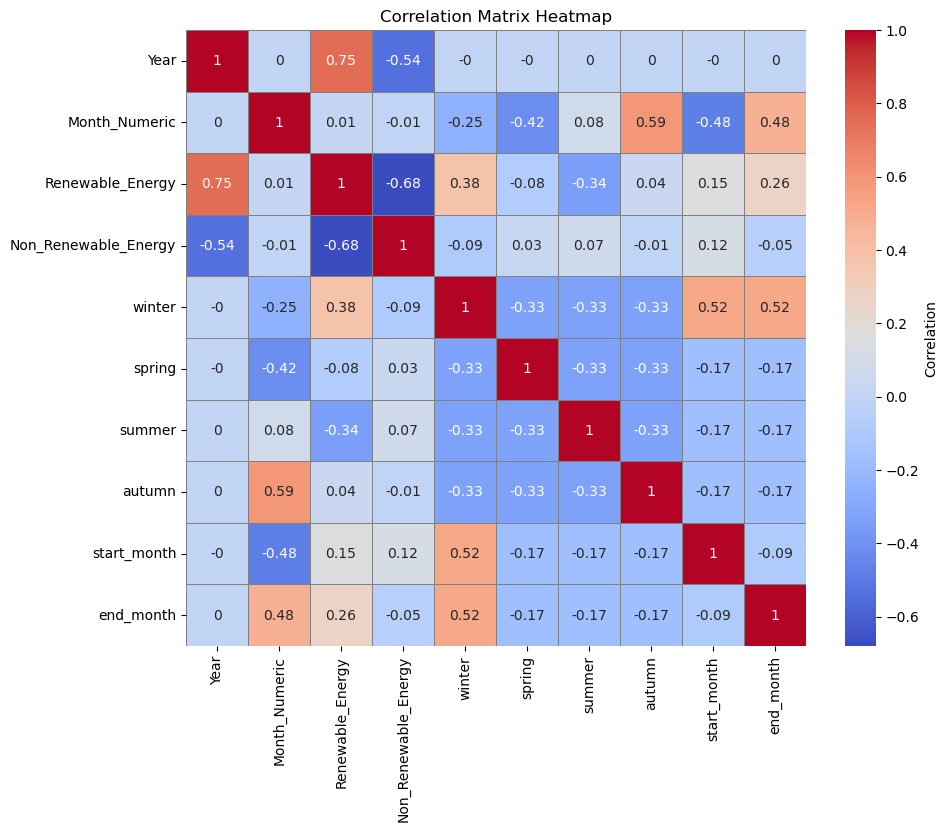

In [48]:
#Add More Features to the Dataset
modelling_data=add_features(ie_power_production_df[['Year', 'Month_Numeric', 'Renewable_Energy', 'Non_Renewable_Energy']])

corr_matrix = modelling_data.corr().round(2)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,     
    cmap='coolwarm',  
    cbar_kws={'label': 'Correlation'}, 
    linewidths=0.5,  
    linecolor='gray'
)

#export_graph('Correlation_Map')

# Add title and display
plt.title('Correlation Matrix Heatmap')
plt.show()

#### Drop Features with Low Correlation

In [50]:
# Drop features using a custom function with built-in error handling
modeling_data=drop_features(modelling_data, features=['spring','autumn','Month_Numeric'])

# Check the dataframe 
modeling_data.head()

,Year,Renewable_Energy,Non_Renewable_Energy,winter,summer,start_month,end_month
Date,,,,,,,
2010-01-01,2010,29.6,175.7,1,0,1,0
2010-02-01,2010,18.1,175.7,1,0,0,0
2010-03-01,2010,24.1,181.4,0,0,0,0
2010-04-01,2010,22.3,159.1,0,0,0,0
2010-05-01,2010,15.6,157.1,0,0,0,0


### 1.3.5 Decomposition of Renewable Energy

Using decomposition, the data was broken down into trend, seasonality, and residuals. This method allows for gaining insight into the structure of the series. The trend component shows an upward trend, indicating a steady increase in energy production over time. The seasonal component exhibits yearly recurring fluctuations or strong seasonality. Lastly, the residuals appear randomly scattered around zero with no observable pattern, which indicates that the trend and seasonality were properly extracted from the original data.

The presence of trend and seasonality in the target variable justifies the use of SARIMA, ANN, and tree-based models for forecasting.

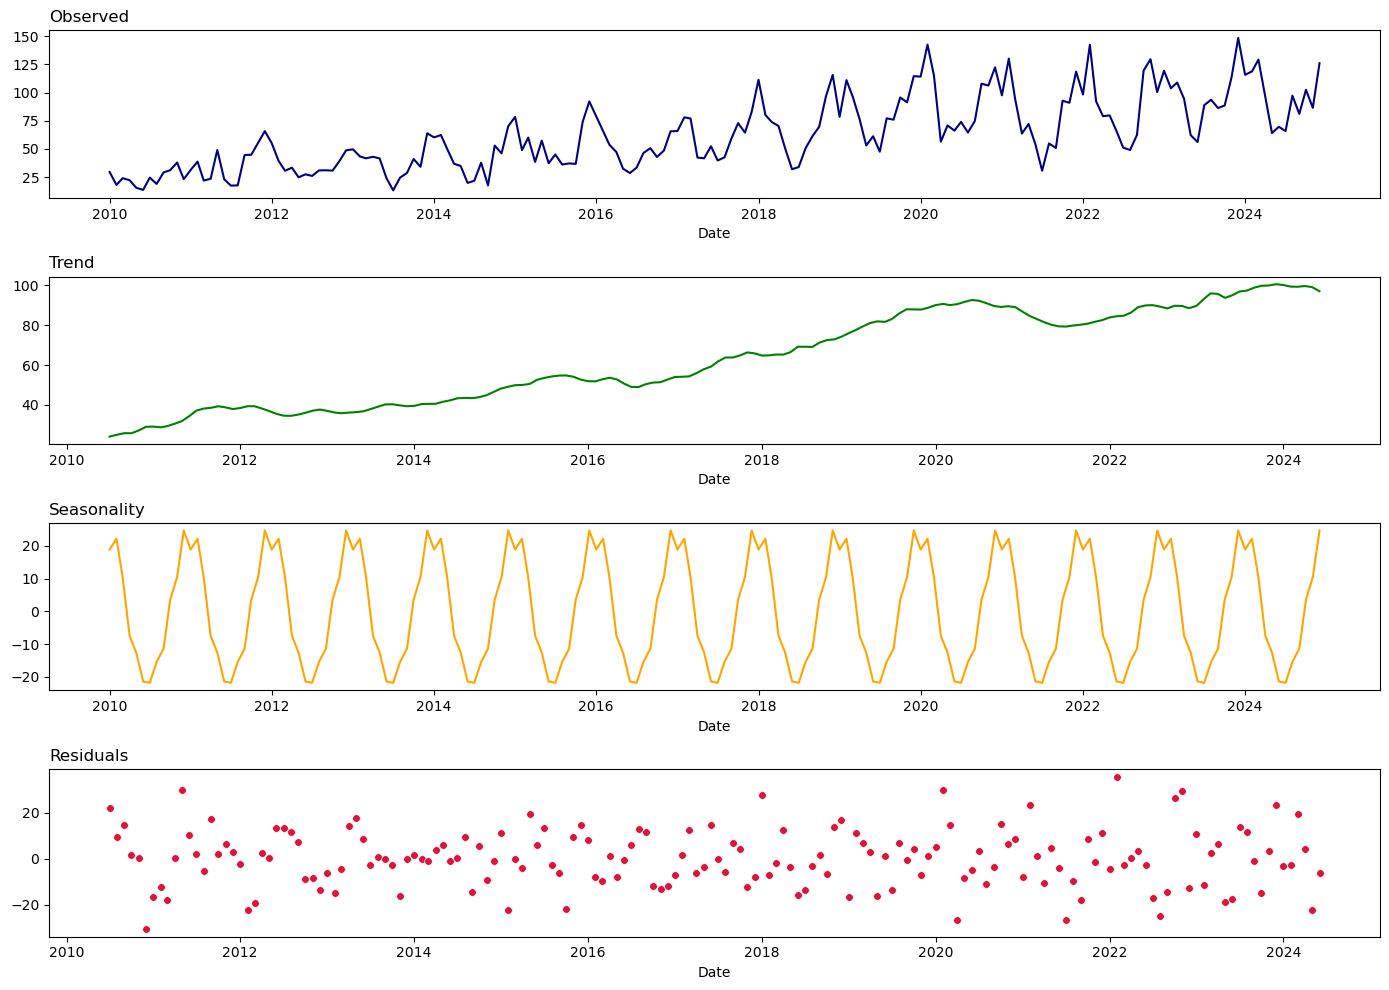

In [53]:
decompose(ie_power_production_df.Renewable_Energy)

## <h2 style="text-align: center; font-family: Arial; font-weight:bold">2. Statistics</h2>
<br />


## 2.1 Descriptive Statistics

### 2.1.1 Measure of Central Tendency

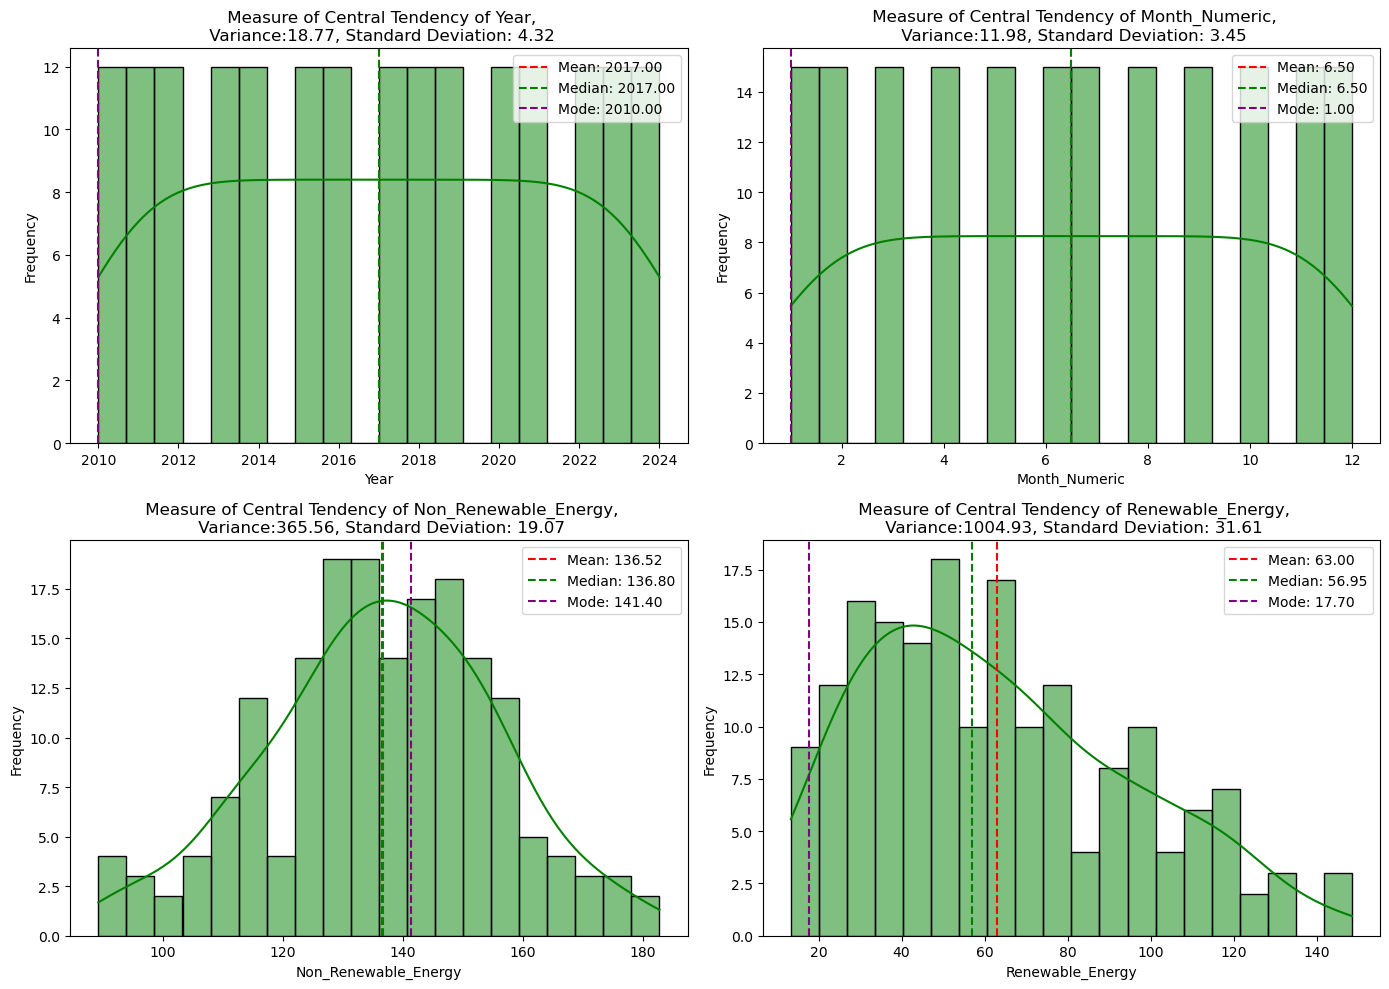

In [57]:
features = ['Year', 'Month_Numeric', 'Non_Renewable_Energy', 'Renewable_Energy']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for index, feature in enumerate(features):
    plot_central_tendency(df=ie_power_production_df, column=feature, ax=axes[index])

plt.tight_layout()
plt.show()

    Analysis:
    
    Year:
    Based on the first graph, the dataset covers from 2010 to 2024. The distribution of the year plot appears to be symmetric or uniform, as supported by the alignment of the mean and the median in 2017. Having a low variance of 18.77 and a standard deviation of 4.32 indicates a consistent distribution of yearly records.
    
    Month Numeric:
    	The result shows a symmetric distribution as the mean and median are at 6.5, which indicates that the monthly data are consistent and do not have more than 1 record each month every year. The feature also shows low variance (11.98) and standard deviation (3.45), indicating an even spread of records.
    
    Non-renewable Energy:
    	The plot exhibits a nearly normal distribution, having the mean (136.5), median (136.8), and mode (141.4)  close to each other. It also indicates that the non-renewable energy consumption is likely stable since there are no visible spikes or outliers in the graph. A variance of 365.5 suggests that the square deviation of the values is moderate, and the standard deviation of 19.07 denotes that the difference in consumption deviates mostly within +-19 values from the mean.
    
    Renewable Energy:
    	There is a significant difference between the mean (63), median (56.95), and the mode (17.70), indicating high variance (1004.93) in the data. The distribution is positively skewed, which suggests that some of the months had very high renewable energy produced. Data should be normalized before proceeding to model training.


### 2.1.2 Transform Data into Normal Distribution 

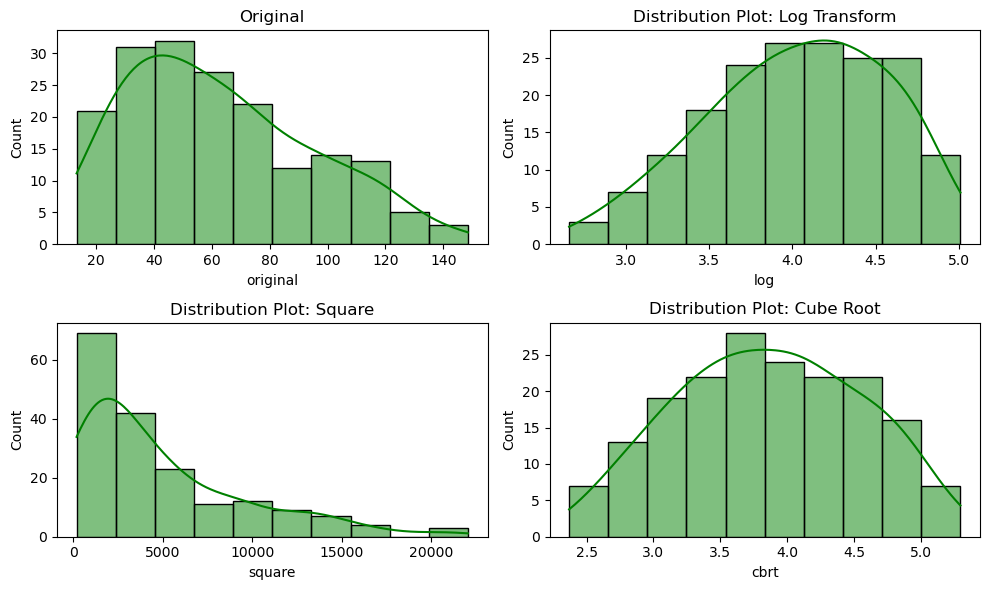

In [60]:
transformed_data=transform_right_skewed(ie_power_production_df.Renewable_Energy)

    Applying transformations to the renewable energy feature, the graph shows that log and cube root transformations effectively normalized the data. Further statistical test was conducted in the hypothesis section to confirm the effectiveness of the transformations.

### 2.1.3 Boxplot of Renewable Energy

In [63]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Box(
    x=ie_power_production_df["Renewable_Energy"],
    orientation='h',
    marker_color='green',
    name='Renewable Energy'
))

fig.update_layout(
    title='Boxplot of Renewable Energy',
    xaxis_title='Energy (ktoe)',
    yaxis=dict(showticklabels=False)
    
)
fig.write_image("./assets/boxplot.png")
fig.show()

### 2.1.3 Binomial Distribution
<b>Statement of the Problem:</b> Based on the monthly energy output, what is the probability that renewable energy output in a given month exceeds the overall average monthly energy production?”

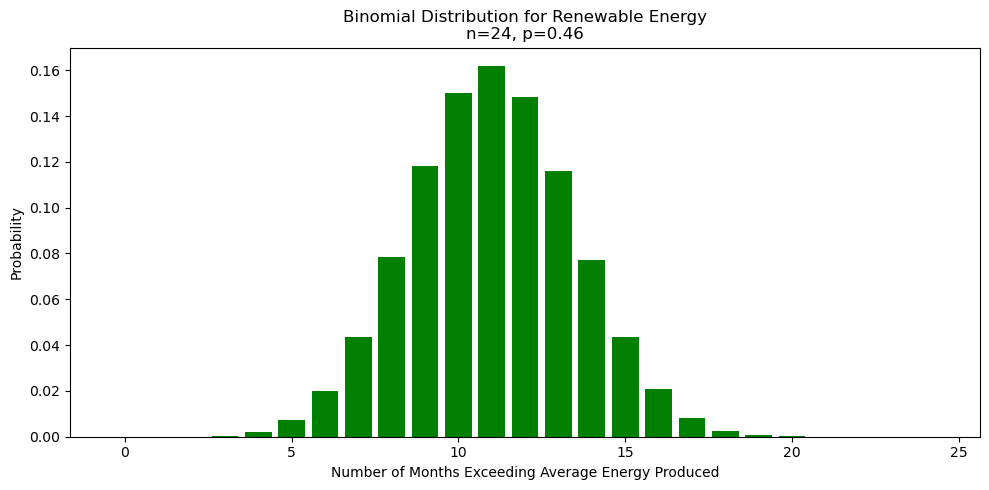

In [65]:
from scipy.stats import binom

binomial_data=ie_power_production_df['Renewable_Energy'].loc[ie_power_production_df.Year > 2022]

# Define threshold by getting the mean
threshold = binomial_data.mean()
binary_outcomes = (binomial_data > threshold).astype(int)

# Count the number of trials and successes
n = len(binary_outcomes)
successes = binary_outcomes.sum()
p = successes / n

# Simulate binomial distribution using binom.pmf funciton
x = np.arange(0, n+1)
binom_dist = binom.pmf(x, n, p)

# Show Plot
plt.figure(figsize=(10, 5))
plt.bar(x, binom_dist, color='green')
plt.title(f'Binomial Distribution for Renewable Energy\nn={n}, p={p:.2f}')
plt.xlabel('Number of Months Exceeding Average Energy Produced')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()

        Through binomial distribution, insight can be gained by summarizing the likelihood of successes in a fixed number of trials using the two independent outcomes (Johansen, 2024). Thus, this graph shows the probability of renewable energy exceeding the average energy output produced. Using values from the years 2023 and 2024, which covers the 24 months of data (n) and p of 0.46, the distribution peaks at 11 months, which indicates that approximately 11 out of 24 months will deliver high renewable energy output, and a 46% chance that it will occur in any given month. Thus, we can consider that fluctuations of the outputs of renewable energy, especially with wind and solar energy, are influenced by seasonal and meteorological conditions. Grid distributors can explore other energy sources or strategies to compensate for lower energy outputs, optimizing grid stability, and improving infrastructure in regards to renewable energy.


### 2.1.4 Scatterplot with Regression Line of Renewable and Non-renewable Energy

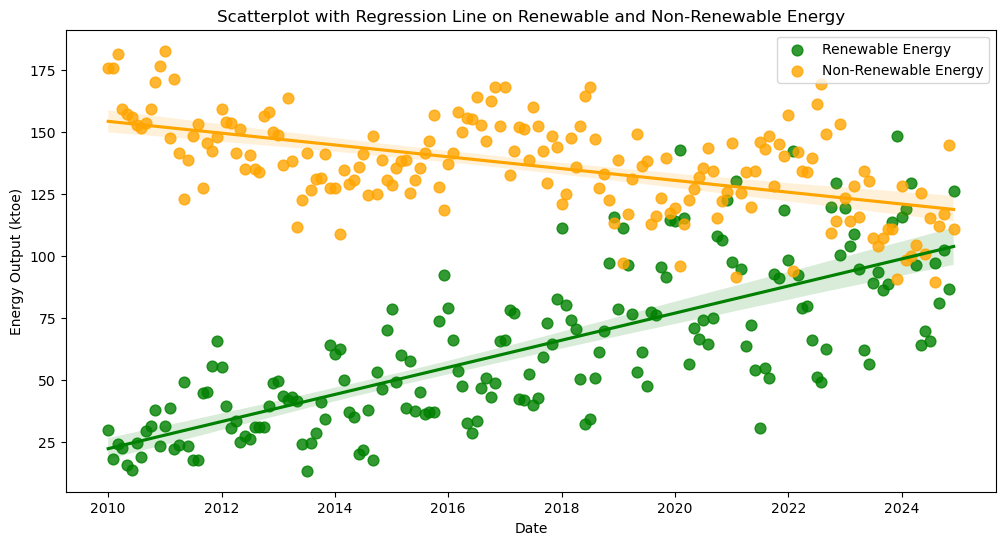

Total freed memory:45.80078125kb.


In [68]:
# Create a copy of the dataframe 
df = ie_power_production_df.copy()

# Create a numeric date index for regression
df['Date'] = df['Year'] + (df['Month_Numeric'] - 1) / 12

# Set figure size
plt.figure(figsize=(12,6))

# Renewable Energy
sns.regplot(
    x='Date',
    y='Renewable_Energy',
    data=df,
    scatter_kws={'s': 60, 'color': 'green'},
    line_kws={'color': 'green'},
    label='Renewable Energy'
)
# Non-Renewable Energy
sns.regplot(
    x='Date',
    y='Non_Renewable_Energy',
    data=df,
    scatter_kws={'s': 60, 'color': 'orange'},
    line_kws={'color': 'orange'},
    label='Non-Renewable Energy'
)
plt.title('Scatterplot with Regression Line on Renewable and Non-Renewable Energy')
plt.xlabel('Date')
plt.ylabel('Energy Output (ktoe)')
plt.legend()
plt.show()

# Delete temporary variable to reduce storage consumption
delete_df('df')

## 2.2 Inferential Statistics

### 2.2.1 Hypothesis Testing on Target Variable

#### Custom Functions for Hypothesis Testing

In [72]:
# Check if data is stationary
#Ho: The data is non stationary
#H1: Data is stationary
def adfuller_test(data):
    result=adfuller(data)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(f'{value:.4f}') )
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("Weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")
    return

# Check id data is in normal distribution
#Ho: Data is in normal distribution
#H1: Data is not in normal distribution
def shapirowilk_test(data, topic='data'):
    stat, p_value = shapiro(data)
    print(f'stats:{stat:.3f}, p_value:{p_value:.3f}')
    if p_value > 0.05:
        print(f'Fail to reject Ho, {topic} is in normal distribution.')
    else:
        print(f'Reject Ho, {topic} is in not normal distribution.')
    
    return


def seasonality_kruskal_test(y, period=12):
    y = np.array(y)
    n = len(y)

    if n < period * 2:
        print("Warning: Not enough data to assess seasonality.")
        return

    # Split y into seasonal groups
    seasonal_groups = [y[i::period] for i in range(period)]

    stat, p = kruskal(*seasonal_groups)
    print(f"Kruskal-Wallis test p-value: {p:.4f}")

    if p < 0.05:
        print("Reject H0: Evidence of seasonality (at least one group differs).")
    else:
        print("Fail to reject H0: No clear evidence of seasonality.")
    print('\n')
    
    return 

#### 1. Adfuller Test on Renewable and Non-renewable Energy
<b>Hypothesis:</b><br />
#Ho: The data is non stationary <br />
#H1: Data is stationary

In [74]:
print('Adfuller test on Non-Renewable Energy')
nonrenewable_shifted_df=ie_power_production_df['Non_Renewable_Energy'].reset_index()
nonrenewable_shifted_df['first_diff']= nonrenewable_shifted_df.Non_Renewable_Energy - nonrenewable_shifted_df.Non_Renewable_Energy.shift(12)
adfuller_test(nonrenewable_shifted_df.first_diff.dropna())

print('\n')
print('Adfuller test on Renewable Energy')
renewable_energy_shifted=ie_power_production_df['Renewable_Energy'].reset_index()
renewable_energy_shifted['first_diff']= renewable_energy_shifted.Renewable_Energy - renewable_energy_shifted.Renewable_Energy.shift(12)
adfuller_test(renewable_energy_shifted.first_diff.dropna())

# Free Memory
delete_df('nonrenewable_shifted_df')
delete_df('renewable_energy_shifted')

Adfuller test on Non-Renewable Energy
ADF Test Statistic : -3.6213
p-value : 0.0054
#Lags Used : 12.0000
Number of Observations Used : 155.0000
Strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


Adfuller test on Renewable Energy
ADF Test Statistic : -5.0850
p-value : 0.0000
#Lags Used : 11.0000
Number of Observations Used : 156.0000
Strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary
Total freed memory:50.1484375kb.
Total freed memory:54.49609375kb.


    Results:
    1. Non-renewable Energy has a p-value of 0.0054, which is below 0.05. Thus, concludes that the data has no unit root or is stationary.
    2. Renewable energy is also below the significance level 0.05 with a p-value of 0.00, indicating the data is stationary.


#### 2. Kruskal Test on Renewable and Non-renewable Energy
<b>Hypothesis:</b><br />
#Ho: There no seasonality in the data. <br />
#H1: Data exhibits seasonality.

In [77]:
print('Renewable Energy:')
seasonality_kruskal_test(ie_power_production_df.Renewable_Energy)

print('Non-renewable Energy:')
seasonality_kruskal_test(ie_power_production_df.Non_Renewable_Energy)

Renewable Energy:
Kruskal-Wallis test p-value: 0.0000
Reject H0: Evidence of seasonality (at least one group differs).


Non-renewable Energy:
Kruskal-Wallis test p-value: 0.4737
Fail to reject H0: No clear evidence of seasonality.




    Results:
    1. Renewable energy exhibits seasonality with a p-value score of 0.00. 
    2. Non-renewable energy has a p-value of 0.47, which is above the significance level of 0.5. Thus, concluding that the data has no seasonality.


#### 3. Shapiro-Wilk Test (Normality)
<b>Hypothesis:</b><br />
#Ho: Data in normal distribution. <br />
#H1: Data exhibits non-normal distribution.

In [80]:
print('Renewable Energy:')
shapirowilk_test(ie_power_production_df.Renewable_Energy)

print('\n')
print('Non-renewable Energy:')
shapirowilk_test(ie_power_production_df.Non_Renewable_Energy)

print('\n')
print('Tests on transformed values:')

print('\n')
print('Renewable Energy Transformed (cbrt):')
shapirowilk_test(transformed_data['cbrt'])

print('\n')
print('Renewable Energy Transformed (log):')
shapirowilk_test(transformed_data['log'])


Renewable Energy:
stats:0.955, p_value:0.000
Reject Ho, data is in not normal distribution.


Non-renewable Energy:
stats:0.994, p_value:0.683
Fail to reject Ho, data is in normal distribution.


Tests on transformed values:


Renewable Energy Transformed (cbrt):
stats:0.985, p_value:0.047
Reject Ho, data is in not normal distribution.


Renewable Energy Transformed (log):
stats:0.977, p_value:0.005
Reject Ho, data is in not normal distribution.


    Results
    1. Renewable energy is not in a normal distribution based on the p-value of 0.00, which is below the significance level.
    2. Non-renewable energy is in normal distribution with a p-value of 0.683.
    
    
    Normality test on the transformed values:
    1. Applying the cuberoot on renewable energy transformed the distribution to a nearly normal but still under the significance level with a p-value of 0.047.
    2. Similarly, the log transformation also falls below the significance level, suggesting that it was not effective in normalising the data.

## 2.3 Comparing Countries using Hypothesis Testing

### 2.3.1 Data Preparation for European Country Comparison

#### World Population Dataset

In [85]:
# Import Dataset
world_population = pd.read_excel('./Datasets/world_population.xlsx')

world_population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,NaN


In [86]:
# Drop irrelevant features

try:
    world_population.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code'], inplace=True)
except:
    print('Error droping columns. No changes have been made.')

# Specify countries as scope of the study
countries=['Ireland', 'Finland', 'Denmark']

# Filter countries that will be used for hypothesis testing
world_population=world_population.loc[world_population['Country Name'].isin(countries)]

# Transform dataset to column countries and years to records
wp_melted = pd.melt(world_population, id_vars='Country Name', var_name='Year', value_name='Population')
wp_transformed = wp_melted.pivot(index='Year', columns='Country Name', values='Population')

# Filter records to year 2005 to 2023
wp_transformed=wp_transformed.loc[(wp_transformed.index>2004) & (wp_transformed.index<2024)]

# Delete unused dataframe 
delete_df('world_population')
delete_df('wp_melted')

# Round off to population to millions
wp_transformed=(wp_transformed/1000000).round(3)


Total freed memory:56.20703125kb.
Total freed memory:75.37890625kb.


#### European Energy Consumption Dataset

In [88]:
# Import European Energy Consumption Dataset
european_consump_df = pd.read_csv('Datasets/final-energy-consumption-eu.csv')

european_consump_df.head()

,DATAFLOW,LAST UPDATE,freq,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2005,100.0,NaN,NaN
1,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2006,100.3,NaN,NaN
2,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2007,98.7,NaN,NaN
3,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2008,98.8,NaN,NaN
4,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2009,95.7,NaN,NaN


In [89]:
print(european_consump_df.isnull().sum())
print(f'Duplicated values: {european_consump_df.duplicated().sum()}')

DATAFLOW          0
LAST UPDATE       0
freq              0
unit              0
geo               0
TIME_PERIOD       0
OBS_VALUE         0
OBS_FLAG       1554
CONF_STATUS    1596
dtype: int64
Duplicated values: 0


In [90]:
# Country Code Mapping
country_code_dict = {
    "AT": "Austria",
    "BE": "Belgium",
    "BG": "Bulgaria",
    "CY": "Cyprus",
    "CZ": "Czech_Republic",
    "DE": "Germany",
    "DK": "Denmark",
    "EE": "Estonia",
    "EL": "Greece",
    "ES": "Spain",
    "EU27_2020": "European_Union",
    "FI": "Finland",
    "FR": "France",
    "HR": "Croatia",
    "HU": "Hungary",
    "IE": "Ireland",
    "IT": "Italy",
    "LT": "Lithuania",
    "LU": "Luxembourg",
    "LV": "Latvia",
    "MT": "Malta",
    "NL": "Netherlands",
    "PL": "Poland",
    "PT": "Portugal",
    "RO": "Romania",
    "SE": "Sweden",
    "SI": "Slovenia",
    "SK": "Slovakia"
}

try:
    # Select required features
    european_consump_df=european_consump_df[['geo','TIME_PERIOD', 'OBS_VALUE']]

    # Rename Columns
    european_consump_df.rename(columns={'geo':'country_code',
                                        'TIME_PERIOD':'year',
                                        'OBS_VALUE':'energy_consumption'}, 
                                        inplace=True)
except:
        print('Error in renaming columns. No changes have been made.')

european_consump_df['country'] = european_consump_df['country_code'].map(country_code_dict)

# Transform dataframe: year as records and countries as features 
european_consump_pivot = european_consump_df.pivot_table(
    index='year',
    columns='country',
    values='energy_consumption',
    aggfunc='mean'
)

# Delete unused dataframe to free up memory
delete_df('european_consump_df')

# Show first 5 reccids
european_consump_pivot.head()

Total freed memory:268.439453125kb.


country,Austria,Belgium,Bulgaria,Croatia,Cyprus,Czech_Republic,Denmark,Estonia,European_Union,Finland,...,Luxembourg,Malta,Netherlands,Poland,Portugal,Romania,Slovakia,Slovenia,Spain,Sweden
year,,,,,,,,,,,,,,,,,,,,,
2005,43.166667,46.256667,37.026667,36.326667,34.760000,42.556667,39.453333,35.003333,373.180000,43.02,...,38.043333,33.880000,51.940000,53.103333,40.270000,41.603333,37.446667,35.886667,66.373333,45.326667
2006,43.296667,45.670000,38.310000,36.393333,35.363333,43.030000,39.893333,35.246667,374.880000,45.26,...,37.410000,34.020000,51.803333,55.426667,39.693333,42.010000,36.430000,35.816667,64.876667,45.356667
2007,42.610000,44.226667,37.806667,36.530000,36.506667,42.106667,39.993333,37.733333,368.430000,45.46,...,36.780000,35.026667,50.883333,55.596667,40.166667,40.873333,36.700000,35.983333,66.683333,45.450000
2008,42.640000,46.133333,37.136667,37.106667,37.406667,42.100000,39.510000,37.430000,371.970000,43.83,...,37.086667,36.540000,51.830000,56.606667,39.083333,42.256667,38.023333,38.473333,64.346667,44.653333
2009,41.306667,44.723333,32.550000,35.990000,36.700000,40.703333,37.660000,33.790000,354.063333,41.02,...,34.466667,33.030000,49.953333,56.066667,38.610000,38.493333,34.800000,34.026667,59.896667,43.376667


### 2.3.2 Hypothesis Testing Comparing European Countries on Energy Consumption 

#### Statement: Based on the latest population count in European countries, Ireland, Denmark, and Finland have comparable population sizes of 5.3M, 6.0M, and 5.6M, respectively (Worldometer, 2025). Using hypothesis testing, we can assess whether there is a similar pattern in energy consumption among these countries

In [92]:
# Set variables to use for testing
ie = european_consump_pivot['Ireland']
dk = european_consump_pivot['Denmark']
fi = european_consump_pivot['Finland']

# Delete unused dataframe to free up memory
delete_df('european_consump_pivot')

Total freed memory:272.744140625kb.


#### Custom Functions

In [94]:
# Define a function to test using pearson correlation
def person_correlation(consumption):
    coef, p_value = pearsonr(wp_transformed[consumption.name], consumption)

    print(f"Checking the correlation of {consumption.name}'s population and energy consumption.")
    print(f"corr_coed:{coef:.3f}, p_value:{p_value:.3f}")
    
    if p_value < 0.05:
        print("Reject the null hypothesis: There is a significant linear correlation.")
    else:
        print("Fail to reject the null hypothesis: No significant linear correlation.")

    plt.figure(figsize=(8, 6))
    sns.regplot(x=wp_transformed[consumption.name], y=ie, color='green', line_kws={"color": "red"})
    plt.title(f"Correlation Plot of {consumption.name}'s Population vs. Energy Consumption")
    plt.xlabel('Population')
    plt.ylabel('Energy Consumption')
    plt.grid(True)
    #export_graph(f'corr_{consumption.name}')
    plt.tight_layout()
    plt.show()

# Define function to do hypothesis testing using Shapiro
def comparing_eu_shapiro(data):
    country=data.name
    print(f"Shapiro-wilk test on {country}'s energy consumption.")
    shapirowilk_test(data, topic=f"{country}'s energy consumption")
    plt.figure(figsize=(8,6))
    sns.histplot(data, bins=10, kde=True, color='green')
    plt.title(f'Shapiro-Wilk Test on Energy Consumption in {country}')
    #export_graph(f'{country}_shap')
    plt.show()


#### 1. Shapiro-Wilk Test on Energy Consumption in Ireland and Denmark

Shapiro-wilk test on Ireland's energy consumption.
stats:0.934, p_value:0.204
Fail to reject Ho, Ireland's energy consumption is in normal distribution.


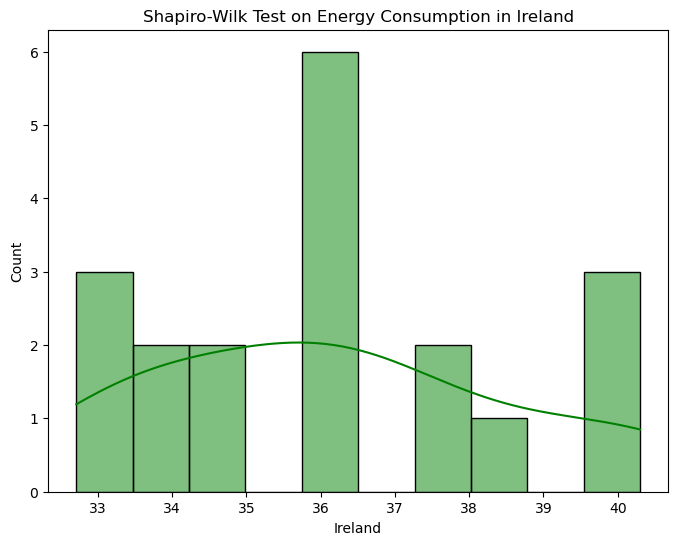

Shapiro-wilk test on Denmark's energy consumption.
stats:0.943, p_value:0.294
Fail to reject Ho, Denmark's energy consumption is in normal distribution.


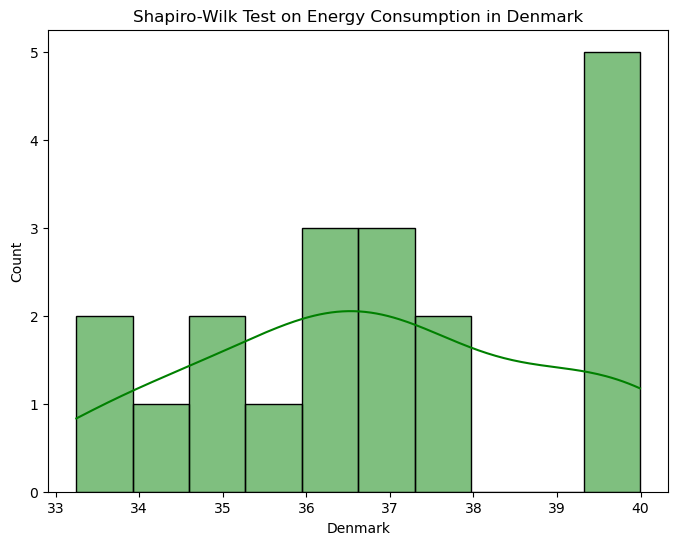

Shapiro-wilk test on Finland's energy consumption.
stats:0.962, p_value:0.614
Fail to reject Ho, Finland's energy consumption is in normal distribution.


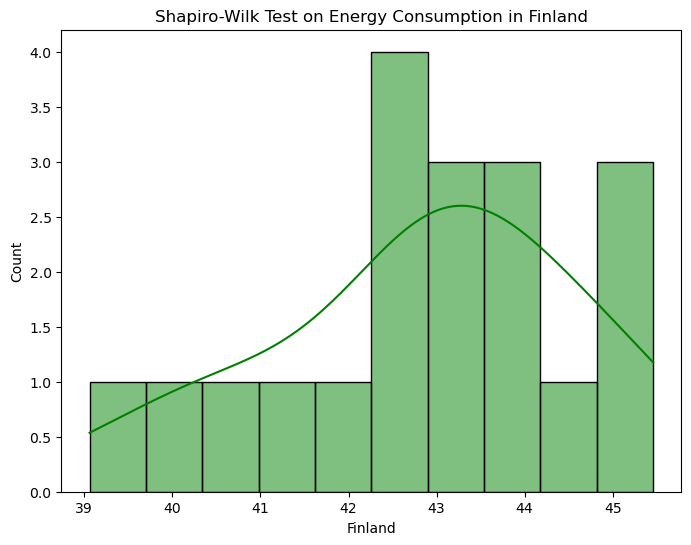

In [96]:
# Hypotheses:
# Ho: Energy consumption is in a normal distribution
# H1: Energy consumption is not in normal distribution
for country in [ie, dk, fi]:
    comparing_eu_shapiro(country)

    Based on the result, Ireland, Finland, and Denmark's energy consumption data are in normal distribution, having a p-value of 0.204, 0.614, and 0.294, respectively. Therefore, the energy consumption values in these countries are close to the average, which also indicates a stable usage of power. Since these datasets are in normal distribution, we can further employ some parametric tests for hypothesis testing.

3. T-test for Ireland and Denmark on Energy Consumption
t-stats:-0.91, p-value: 0.37
-> Fail to reject the null hypothesis: There is no significant difference in the average energy consumption between Ireland and Denmark


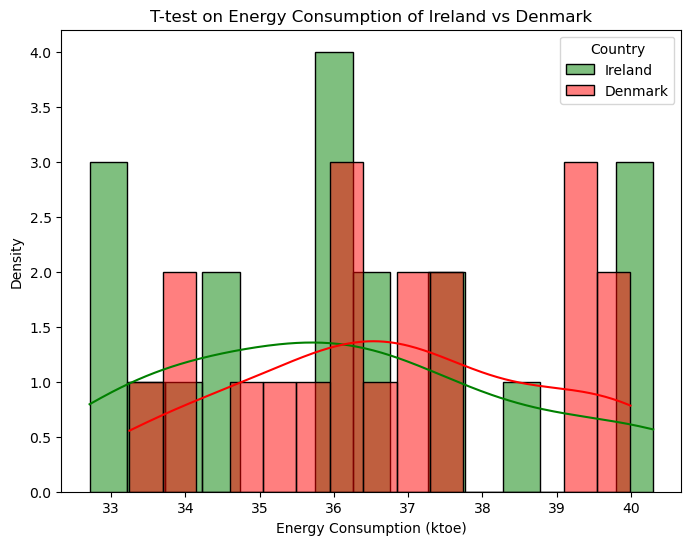

In [98]:
# 2. T-test for Ireland and Denmark on Energy Consumption
# Ho: The average energy consumption is equal between Ireland and other European countries.
# H1: The average energy consumption in Ireland differs from Denmark.  
t_stat, p_val = ttest_ind(ie, dk)

print('3. T-test for Ireland and Denmark on Energy Consumption')
print(f't-stats:{t_stat:.2f}, p-value: {p_val:.2f}')
if p_val < 0.05:
    print("-> Reject the null hypothesis: There is a significant difference in the average energy consumption between Ireland and Denmark.")
else:
    print("-> Fail to reject the null hypothesis: There is no significant difference in the average energy consumption between Ireland and Denmark")

plt.figure(figsize=(8, 6))
sns.histplot(ie, kde=True, label='Ireland', bins=15, color='green')
sns.histplot(dk, kde=True, label='Denmark', bins=15, color='red')
plt.xlabel("Energy Consumption (ktoe)")
plt.ylabel("Density")
plt.title('T-test on Energy Consumption of Ireland vs Denmark')
plt.legend(title="Country")
#export_graph('Ttest_eu')
plt.show()

    A  t-test was applied to compare Ireland and Denmark’s consumption of energy. The result of the p-value of 0.37 concludes there is no statistical evidence to reject the null hypothesis. Therefore, there is no significant difference in the average energy consumption between the two countries.

Checking the correlation of Ireland's population and energy consumption.
corr_coed:-0.340, p_value:0.155
Fail to reject the null hypothesis: No significant linear correlation.


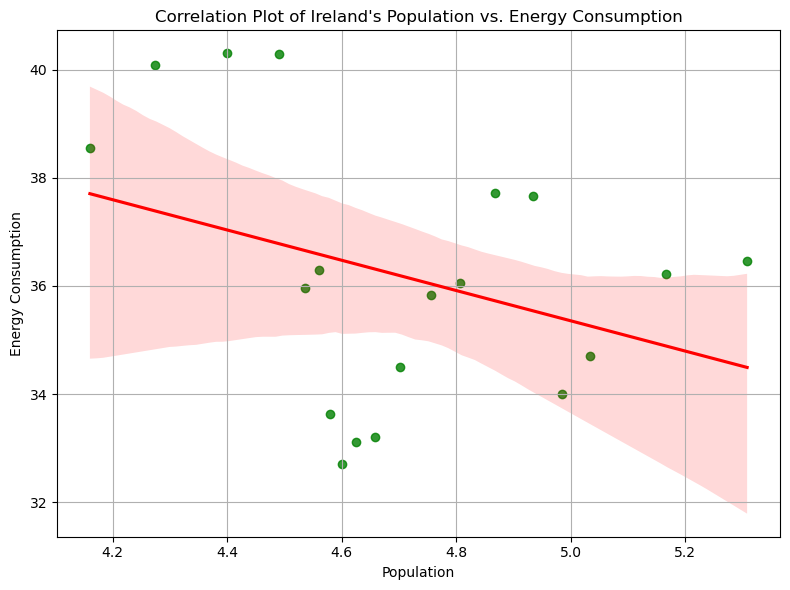

Checking the correlation of Finland's population and energy consumption.
corr_coed:-0.539, p_value:0.017
Reject the null hypothesis: There is a significant linear correlation.


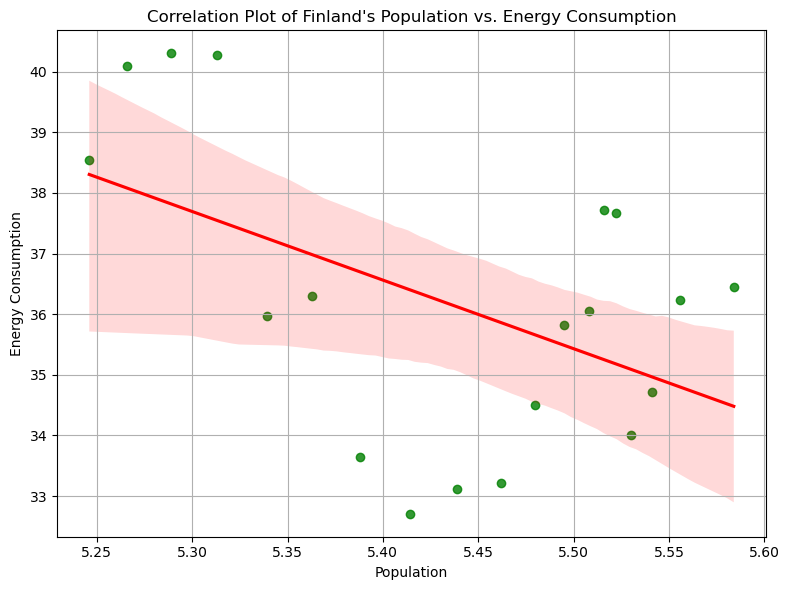

Checking the correlation of Denmark's population and energy consumption.
corr_coed:-0.842, p_value:0.000
Reject the null hypothesis: There is a significant linear correlation.


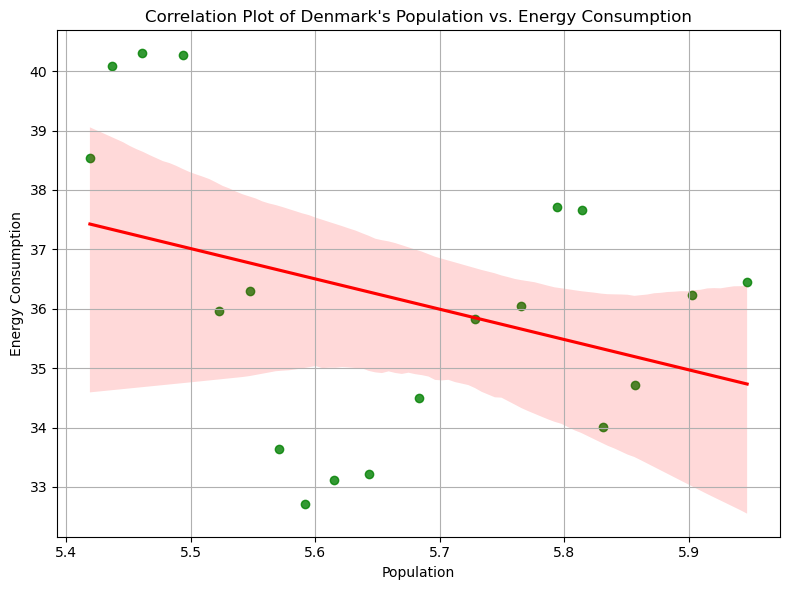

In [100]:
# 3. Pearson Correlation on population and energy consumption
# Ho: There is no significant linear correlation between population and energy consumption.
# H1:  There is significant evidence of a linear correlation between population and energy consumption.
for country in [ie, fi, dk]:
    person_correlation(country)

The result shows Ireland’s increase in population does not correlate with an increase in energy consumption, with a p-value of 0.155, which is above the significance level of 0.05. On the other hand, both Finland and Denmark have a significant linear correlation between the population and energy consumption, with the corresponding p-values of 0.17 and 0.00, respectively.

Reject the null hypothesis: There is a significant difference between the means of the groups.
F-statistic: 57.215517289363156
p-value: 4.583891986094953e-14


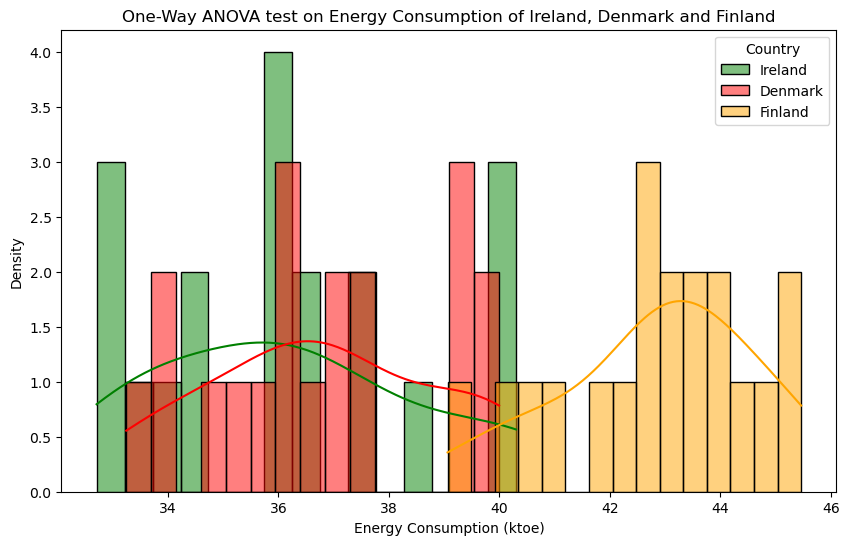

In [102]:
# 4. Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(ie, fi, dk)

# Set significance level (alpha)
alpha = 0.05

# Compare p-value with significance level to make a decision
if p_value <= alpha:
    result = f"Reject the null hypothesis: There is a significant difference between the means of the groups.\nF-statistic: {f_stat}\np-value: {p_value}"
else:
    result = f"Fail to reject the null hypothesis: There is no significant difference between the means of the groups.\nF-statistic: {f_stat}\np-value: {p_value}"

# Display the decision
print(result)
plt.figure(figsize=(10, 6))
sns.histplot(ie, kde=True, label='Ireland', bins=15, color='green')
sns.histplot(dk, kde=True, label='Denmark', bins=15, color='red')
sns.histplot(fi, kde=True, label='Finland', bins=15, color='orange')
plt.xlabel("Energy Consumption (ktoe)")
plt.ylabel("Density")
plt.title('One-Way ANOVA test on Energy Consumption of Ireland, Denmark and Finland')
plt.legend(title="Country")
#export_graph('anova_test')
plt.show()

    Results conclude that there is a significant difference between the average energy consumption despite having similar population sizes, where Ireland and Denmark peak at around 34 to 38 ktoe. On the other hand, Finland has higher energy consumption from 37 to 45 ktoe and peaks at 43.

#### Conclusion:
    Overall, the results suggest Finland’s energy consumption is higher, which might be influenced by factors other than population, such as industrial demand or climate. In contrast, Ireland and Denmark show similarities in energy usage, which can be an opportunity to share policies and best practices to optimize energy usage, especially with more sustainable development that will help both countries. 



## <h2 style="text-align: center; font-family: Arial; font-weight:bold">3. Machine Learning</h2>
<br />


### Custom Functions

In [107]:
# Create a variable to store model training results
results=[]
train_test_comp=[]

####------------------------------------------------------------------------------------Model Training Functions

# Initialize Model Training with SARIMA
# data - Date as index, and target variable only as column
# order - set order (p, d q)
# seasonal_order - set seasonal order (P, D, Q, S)
# use_pmdarima - True - find best order and seasonal order, else use specified values
def train_sarima(data, order, seasonal_order, use_pmdarima=False, export_model=False):
    # Start Runtime Timer
    timer.start()

    sarima_data=data.reset_index().set_index('Date')

    # Train test split 80% Train and 20% allocated for test
    split_idx = int(len(sarima_data) * 0.8)
    train = sarima_data[:split_idx]
    test = sarima_data[split_idx:]

    # Check if to use pmdARIMA
    # Yes: Run & deploy generated best pdq and PDQS 
    if use_pmdarima == True:
        model=run_pmdarima(train)
        order=model.order
        seasonal_order=model.seasonal_order
    else:
        pass

    print(f'Utilizing pdq values: {order},and seasonal order:{seasonal_order}.')

    # Fit SARIMA
    model = SARIMAX(train, order=order, seasonal_order=seasonal_order)
    results = model.fit(disp=False)
    
    # Forecast
    forecast = results.get_forecast(steps=len(test))
    mean_forecast = forecast.predicted_mean
    conf_int = forecast.conf_int()
    
    # Result for train
    train_pred = results.fittedvalues
    
    # Calculate R2 score for train and 
    train_r2, train_rmse, train_mae = calculate_metrics(train[1:], train_pred[1:],'SARIMA', record_scores=False)
    test_r2, test_mse, test_mae = calculate_metrics(test, mean_forecast,'SARIMA', record_scores=True)
    print(f'R2 score for train {train_r2:.2f} and test {test_r2:.2f}.')
    test_pred = pd.Series(forecast.predicted_mean, index=test.index)
    
    # Plot Results
    plot_results(train, train_pred, test, test_pred, test_mse, test_r2, 'SARIMA')

    # Export Model
    if export_model:
        try:
            with open('assets/model/sarima_model.pkl', 'wb') as f:
                pickle.dump(results, f)
                print('Model exported sucessfully.')
        except Exception as e:
            print(f'Error exporting model:{e}')
        
    # Stop Timer
    timer.stop()



### Create a function to run pmdARIMA
# data - provide train data
def run_pmdarima(data):
    #Find best pdq and PDQ
    model = pm.auto_arima(
                        data,
                        start_p=0, 
                        start_q=0,
                        max_p=2, 
                        max_q=2,
                        start_P=0, 
                        start_Q=0,
                        max_P=2, 
                        max_Q=2,
                        seasonal=True,
                        m=12,  # seasonal period
                        d=None,
                        D=None,          
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True,           
                        n_fits=50)
    
    print(model.summary())
    return model




### Initialize Model Training with ANN
# data - Dataframe to train (make sure target is at 0 column)
# visualize_datasplit - visualize datasplit through graph
def train_ann(data, visualize_datasplit=True):
    # Start runtime timer
    timer.start()

    # Apply Scaler
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaled = scaler.fit_transform(data)
    
    X = scaled[:, 1:]  # Lag features
    y = scaled[:, 0]   # Target Value : Renewable Energy
    
    split_idx = int(len(X) * 0.80)
    X_train, X_test = X[:split_idx+1], X[split_idx:]
    y_train, y_test = y[:split_idx+1], y[split_idx:]
    
    # Set figure size
    plt.figure(figsize=(10, 5))  

    # Turn on and of datasplit visualization
    if visualize_datasplit == True:
        # Plot Train and Test data
        sns.lineplot(x=modeling_data_lags.index[0:len(y_train)], y=y_train, label='Train', color='green')
        sns.lineplot(x=modeling_data_lags.index[len(y_train)-1:len(y_train)+len(y_test)], y=y_test, label='Test', color='orange')
        plt.title(f"Data Split Visualization")
        plt.xlabel('Date')
        plt.ylabel('Energy (ktoe)')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        pass
    
    # Initialize ANN Model using Sequential
    ann_model=Sequential()
    ann_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
    ann_model.add(Dropout(0.3))  # Dropout to reduce overfitting
    ann_model.add(Dense(32, activation='relu'))
    ann_model.add(Dense(1))
    ann_model.compile(loss='mean_squared_error', optimizer='adam', metrics = [RootMeanSquaredError()])
    early_stop = EarlyStopping(monitor='loss', patience=3, verbose=1)
    
    # Train the Model
    history = ann_model.fit(X_train, y_train, epochs=100, batch_size=1, verbose=1, callbacks=[early_stop], shuffle=False)
    
    # Get Predictions for Train and Test
    ann_y_test_pred = ann_model.predict(X_test)
    ann_y_train_pred = ann_model.predict(X_train)
    
    # Get score metrics
    r2_train, mse_train, train_mae=calculate_metrics(y_train, ann_y_train_pred, 'ANN', record_scores=False)
    r2_test, mse_test, test_mae=calculate_metrics(y_test, ann_y_test_pred, 'ANN', record_scores=False)
    print(f'R2 score for train {r2_train:.2f} and test {r2_test:.2f}.')
    
    # Inverse scale results
    X_pred = scaler.inverse_transform(np.hstack([ann_y_train_pred.reshape(-1, 1), X_train]))[:, 0]
    X_train_actual = scaler.inverse_transform(np.hstack([y_train.reshape(-1, 1), X_train]))[:, 0]
    y_pred = scaler.inverse_transform(np.hstack([ann_y_test_pred.reshape(-1, 1), X_test]))[:, 0]
    y_test_actual = scaler.inverse_transform(np.hstack([y_test.reshape(-1, 1), X_test]))[:, 0]
    
    # Recalculate the actual prediction score
    r2_pred, rmse_pred, mae = calculate_metrics(y_test_actual, y_pred, 'ANN', record_scores=True)
    
    # Plot Results
    plot_results(X_train_actual, X_pred, y_test_actual, y_pred, rmse_pred, r2_pred, 'ANN')
    
    # Get End time and compute for runtime
    timer.stop()


# ###This function will initialize model training for tree-based models
# X - independent variables
# y - target variables
# model - dictionary of models to be used
# param_grid - corresponding parameter grid per model
# split_size - train, test split size with 20% default
# cv - number of folds
def init_training(X, y, model, param_grid, split_size=0.20, cv=3, print_results=True, record_scores=True):

    # Create Train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = split_size, random_state=0, shuffle = False)
    
    # Create variables to store model and results
    trained_models={}

    #Loop through each model
    for name, model in models.items():
        # Use GridsearchCV to get the best hyperparameters
        grid_search = GridSearchCV(model, param_grid[name], cv=cv, scoring='neg_mean_squared_error') 
        
        # Fit the grid search
        grid_search.fit(X_train, y_train)
        
        # Best parameters and best score
        best_params = grid_search.best_params_
        best_score = grid_search.best_score_
        
        # Get best model on the training data
        best_model = grid_search.best_estimator_

        # Predict Values
        X_pred = best_model.predict(X_train)
        y_pred = best_model.predict(X_test)
        
        # Calculate R2, MAE and MSE
        train_r2, train_mse, train_mae = calculate_metrics(y_train, X_pred, model=name)
        test_r2, test_mse, test_mae = calculate_metrics(y_test, y_pred, model=name, record_scores=record_scores)

        # Store best model
        trained_models[name]= best_model
        
        # Display the training and test score
        if print_results: 
            print(f'Model: {name}:')
            print(f'Best Params:{best_params}')
            print(f'R2 score train:{train_r2: .4f}, test:{test_r2: .4f}.')
            print(f'Train MAE: {train_mae}, Test MAE: {test_mae}')
            print(f'Train MSE: {np.sqrt(train_mse)}, Test RMSE: {test_mse}')
            print('\n')
            plot_results(y_train, X_pred, y_test, y_pred, test_mse, test_r2, model=name)
    
    # Return model training results and trained_models to be used for predictions
    return test_r2, trained_models


####------------------------------------------------------------------------------------Metrics and Visalization


### Plot Results of Train and Test
# train_actual - Train actual values
# train_pred - Predicted train values
# test_actual - Actual values for test
# test_pred - Prediction for test values
# test_mse - RMSE Score
# test_r2 - R2 Score
# model - Model employed 
def plot_results(train_actual, train_pred, test_actual, test_pred, test_mse, test_r2, model=''):
    # Plot results
    plt.figure(figsize=(12, 6))

    # If Model is ANN
    if model == 'ANN':
        # Shift 1 year as seen on index[12 and +12]
        sns.lineplot(x=ie_power_production_df.index[12:len(train_actual)+12], y=train_actual, label='Train Data', color='green')
        sns.lineplot(x=ie_power_production_df.index[12:len(train_actual)+12], y=train_pred, label='Train Prediction', color='blue')
        sns.lineplot(x=ie_power_production_df.index[-len(test_actual):], y=test_actual, label='Test Data', color='orange')
        sns.lineplot(x=ie_power_production_df.index[-len(test_pred):], y=test_pred, label='Test Prediction', color='red')
   # Use if other models
    else:
        plt.plot(train_actual.index, train_actual, label='Training Data', color='green')
        plt.plot(train_actual.index, train_pred, label='Training Prediction', color='blue')
        plt.plot(test_actual.index, test_actual, label='Test Data', color='orange')
        plt.plot(test_actual.index, test_pred, label='Test Prediction', color='red')

    # Change Labels and titles
    plt.title(f"Renewable Energy Forecast using {model}\nRMSE: {test_mse:.2f}, R²: {test_r2:.2f}")
    plt.xlabel("Date")
    plt.ylabel("Renewable Energy (ktoe)")

    # Show graph
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    export_graph(filename=model, graph_type='plt')
    plt.show()


### This function displays a performance comparison across all trained models
# result - compiled metrics of model results
# title - set title of the graph
def gen_model_training_summary(result,title=''):
    # Convert to DataFrame and sort by R2 score
    results_df = pd.DataFrame(results).sort_values(by='R2', ascending=True)
    
    # Create subplots
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot R² Score
    sns.barplot(ax=ax[0], x=results_df.Model, y=results_df.R2, palette="Blues")
    ax[0].set_title("R2 Score Comparison")
    ax[0].set_ylabel("R2 Score")
    ax[0].set_xticklabels(results_df.Model, rotation=20, ha="right")
    
    # Plot MAE
    sns.barplot(ax=ax[1], x=results_df.Model, y=results_df.MAE, palette="Greens")
    ax[1].set_title("Mean Absolute Error (MAE) Comparison")
    ax[1].set_ylabel("MAE")
    ax[1].set_xticklabels(results_df.Model, rotation=20, ha="right")
    
    # Plot RMSE
    sns.barplot(ax=ax[2], x=results_df.Model, y=results_df.RMSE, palette="Oranges")
    ax[2].set_title("Root Mean Squared Error (RMSE) Comparison")
    ax[2].set_ylabel("RMSE")
    ax[2].set_xticklabels(results_df.Model, rotation=20, ha="right")
    
    # Adjust layout and show plot
    plt.suptitle(title)
    plt.tight_layout()

    export_graph('model_summary')
    plt.show()



### Calculate metrics for machine learning results
# data - actual data
# pred_data - prediction result 
# model - specify if ANN or SARIMA
def calculate_metrics(data, pred_data, model, record_scores=False):
    # Compute for R2, MSE, MAE
    rmse = np.sqrt(mean_squared_error(data, pred_data))
    mae = mean_absolute_error(data, pred_data)
    r2 = r2_score(data, pred_data)

    # Store results if store is true
    if record_scores:
        results.append({'Model':model, 'R2': r2, 'MAE':mae, 'RMSE': rmse})

    # Return Metrics
    return r2, rmse, mae 


## 3.1 Forecasting using Artificial Neural Networks

### 3.1.1 Train Model

Epoch 1/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - loss: 0.2071 - root_mean_squared_error: 0.4333 
Epoch 2/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - loss: 0.0888 - root_mean_squared_error: 0.2948
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 365us/step - loss: 0.0565 - root_mean_squared_error: 0.2362
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - loss: 0.0513 - root_mean_squared_error: 0.2257
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - loss: 0.0497 - root_mean_squared_error: 0.2217
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - loss: 0.0505 - root_mean_squared_error: 0.2238
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - loss: 0.0397 - root_mean_squared_error: 0.1981
Epoch 8/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step - loss: 0.0389 - root_mean_squared_error: 0.1962
Epoch 9/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - loss: 0.0483 - root_mean_squared_error: 0.2185
Epoch 10/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step - loss:

<Figure size 1000x500 with 0 Axes>

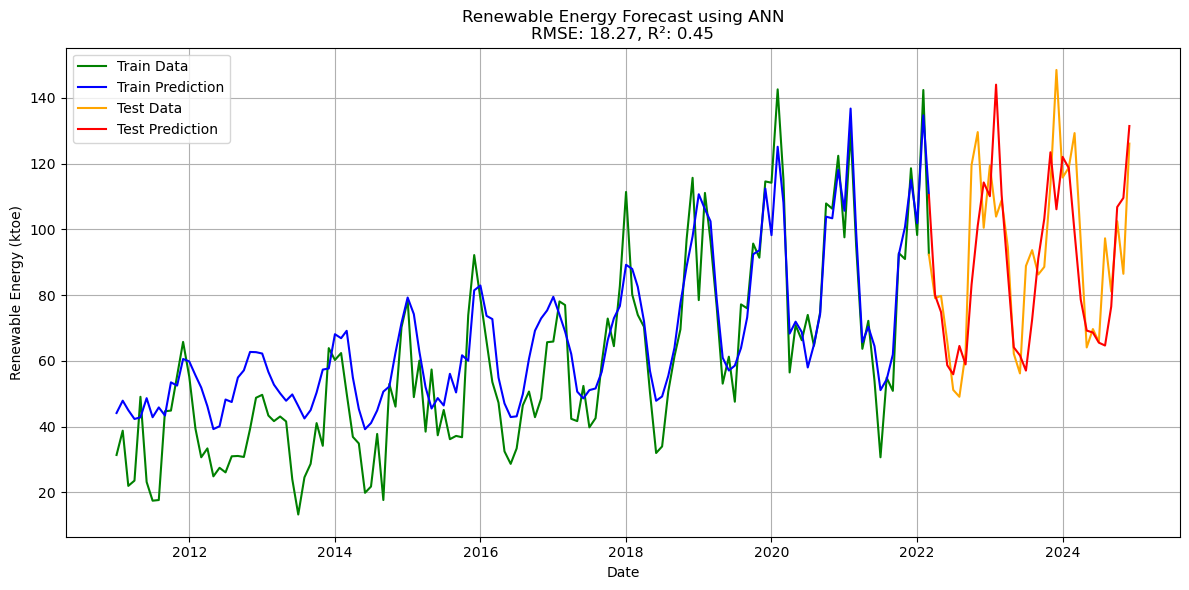

Runtime: 2.135 seconds.


In [110]:
# Add Lag Values
modelling_data_lags = generate_lag_features(ie_power_production_df['Renewable_Energy'], 12)

# Train Model with lags only
train_ann(modelling_data_lags, visualize_datasplit=False)

    The ANN model worked well on the training phase with an R2 score of 0.77, but struggled with generalization, having an R2 score of 0.44. RMSE is at 18.97, resulting in an average deviation of ±18.97 ktoe between the predicted and actual values. Results differ every run as layers were initiated with random weights before training starts.

## 3.2 Seasonal AutoRegressive Integrated Moving Average (SARIMA)

### ACF, PACF plot

#### First Differencing

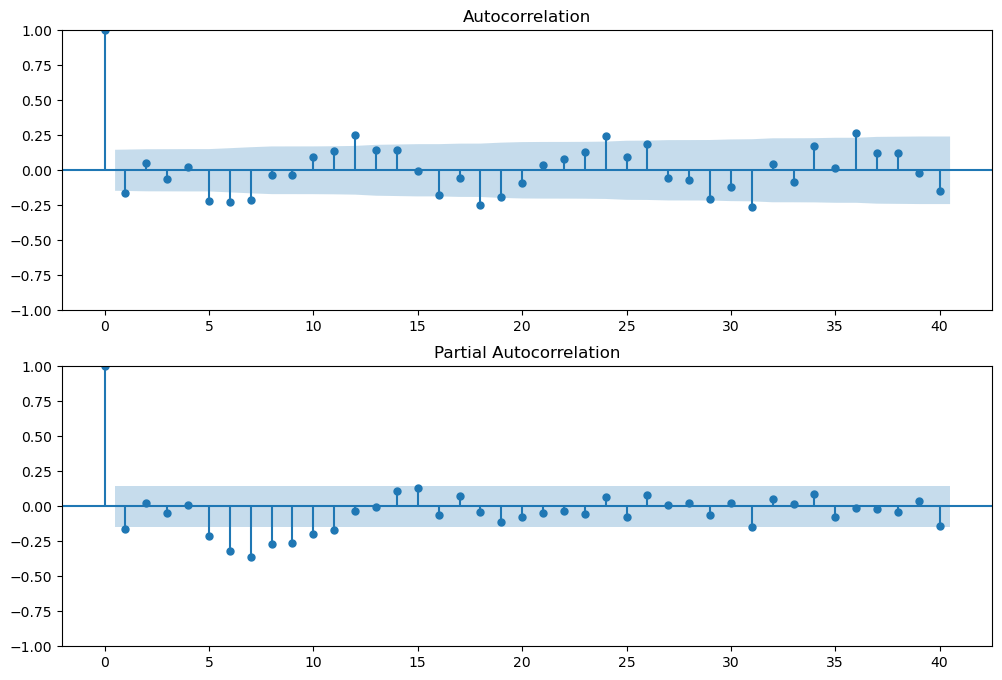

In [115]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.api as sm

# First Differencing
plt.style.use('default')
renewable_data_shifted= ie_power_production_df.Renewable_Energy.diff(1)
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(renewable_data_shifted.dropna(),lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(renewable_data_shifted.dropna(),lags=40,ax=ax2)
plt.show()

    Based on the Autocorrelation(ACF) graph, there is a noticeable spike at lag 1 and gradually decays, similar to the Partial Autocorrelation Plot(PACF). Thus, suggest an AR and MA value of 1. 

#### Seasonal Differencing

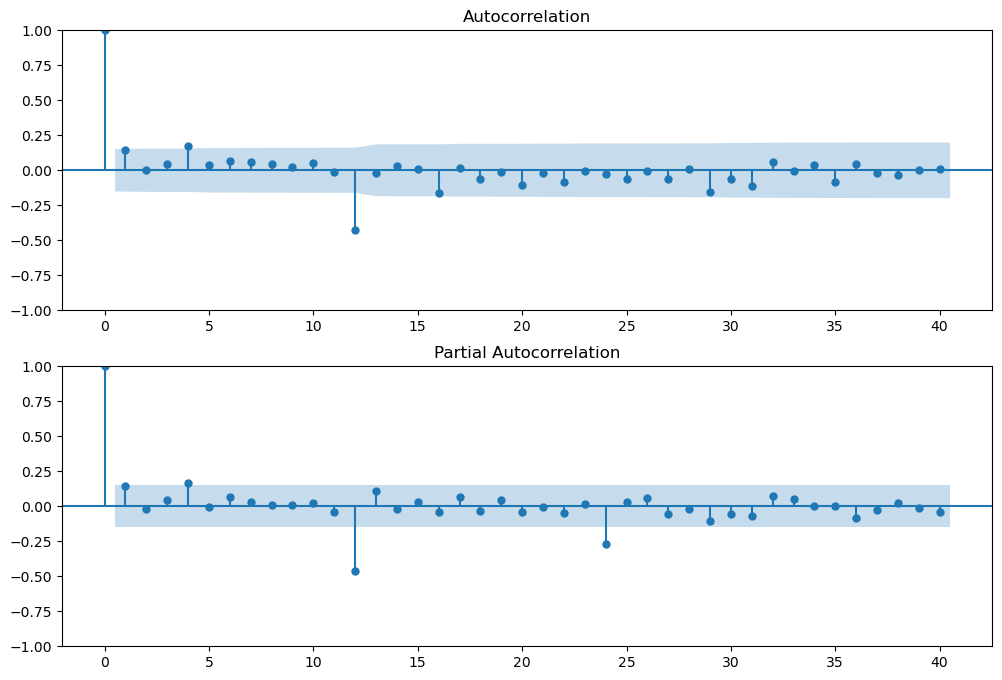

In [118]:
# Seasonal Differencing
plt.style.use('default')
renewable_data_shifted= ie_power_production_df.Renewable_Energy.diff(12)
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(renewable_data_shifted.dropna(),lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(renewable_data_shifted.dropna(),lags=40,ax=ax2)
plt.show()

    For the seasonal order calculations, values are in monthly data (s=12). Checking seasonal differencing (D) using the Adfuller test, the data indicates stationarity(D=1).  Using ACF and PACF plots, P = 0, since the PACF plot does not show a significant seasonal spike, and Q was determined to be either 1 or 0, given that seasonal lags appear weak.  Therefore, the seasonal order (P, D, Q, s) =  (0, 1, [0,1], 2).

### 3.1.1 Train Model

Utilizing pdq values: (1, 1, 5),and seasonal order:(1, 0, 1, 12).
R2 score for train 0.78 and test 0.65.
Graph exported.


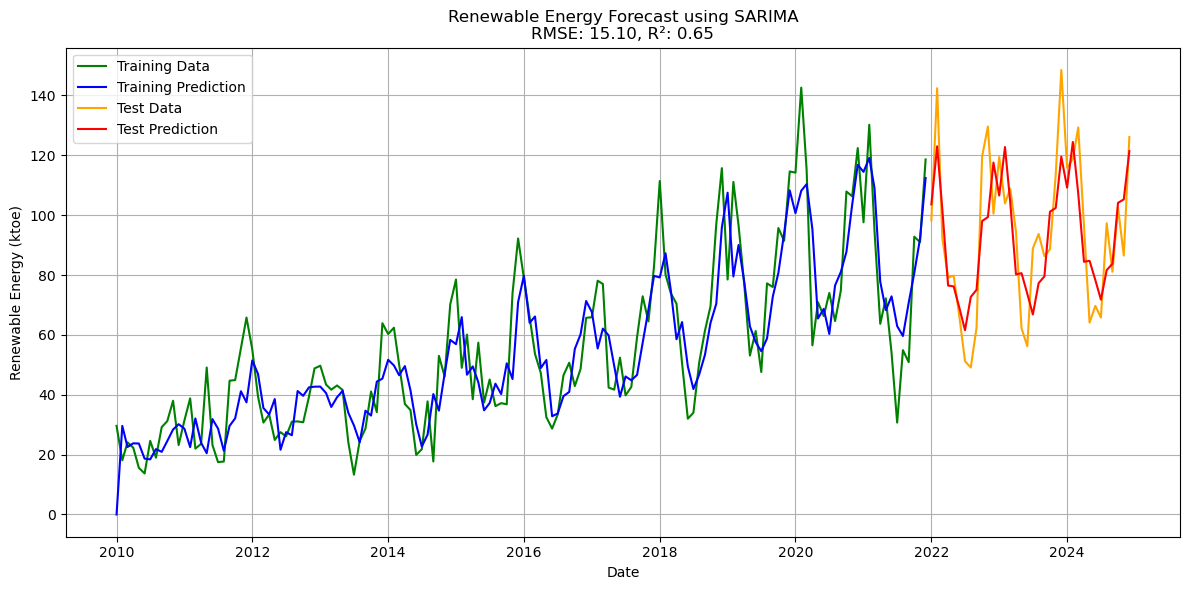

Runtime: 1.250 seconds.


In [121]:
train_sarima(ie_power_production_df['Renewable_Energy'], (1,1,5), (1,0,1,12), use_pmdarima=False)

    Training the model with values (1, 1, 1) and seasonal order of (1, 0, 1, 12), the root mean square error (RMSE) is at 15.53 ktoe with an R2 score of 0.63. However, tweaking order values to (1, 1, 5) results in an improved score of 15.10 ktoe for RMSE and 0.65 R2 score. Train and test R2 scores shows no sign of overfitting.

## 3.3 Tree-Based Models (Random-Forest and XGBoost Regressor)

In [124]:
# Add lags and features
modelling_data_features = add_features(ie_power_production_df[['Renewable_Energy', 'Month_Numeric']])
modelling_data_features = modelling_data_features.drop(columns=['Renewable_Energy'])
modelling_data = modelling_data_lags.join(modelling_data_features, how='left')


# Identify Target and Independent Variables
X = modelling_data.iloc[:,1:] # Independent Variables
y = modelling_data.iloc[:, 0] # Renewable Energy

### Find Optimal Cross Validation Value

Analyzing best CV value...
Runtime: 1.556 seconds.
Runtime: 2.433 seconds.
Runtime: 3.134 seconds.
Runtime: 3.873 seconds.
Runtime: 4.687 seconds.


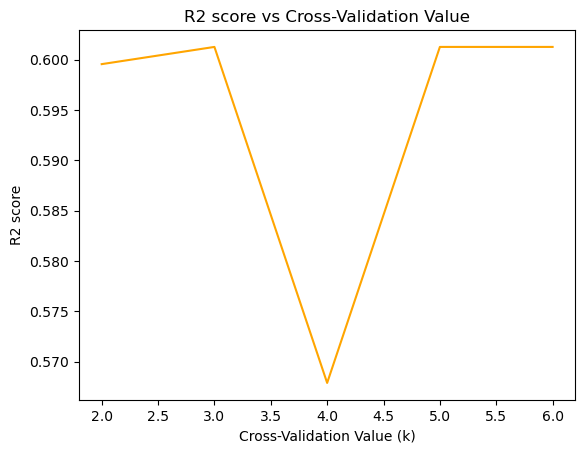

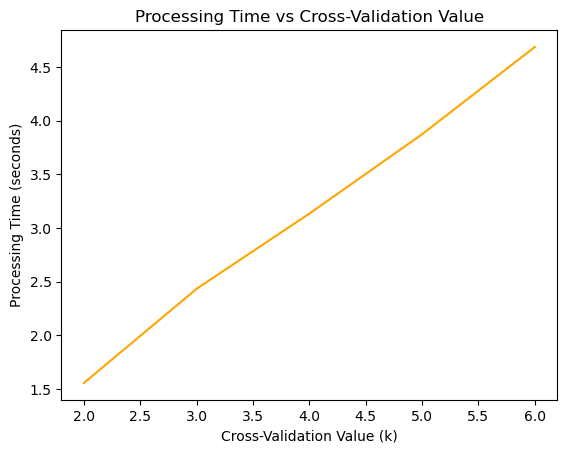

In [126]:
# Declare parameter grid for random forest and xgboost
param_grid = {
    'Random Forest': {
        'n_estimators': [50, 100],             
        'max_depth': [4, 6, 8],         # Shallower trees reduce overfitting
        'min_samples_split': [5, 10],     # create more splits before branching
        'min_samples_leaf': [2, 4],        # Leaf must contain more samples
        'max_features': ['sqrt'],      # Subsample features per tree
        'random_state': [0]
    }
}

# Define Models in the dictionary
models = {
    "Random Forest": RandomForestRegressor()
}

# Create a Variable to store results 
cv_results=[]

# Loop values in range of 2-6 to get the best cv value
print('Analyzing best CV value...')
for cv in range(2,7):
     timer.start()
     R2, predictons = init_training(X, y, models, param_grid, cv=cv, print_results=False, record_scores=False)
     timer.stop()
     cv_results.append({'cv':cv, 'R2':R2, 'processing_time':timer.get_results()})

# Show results
sns.lineplot(pd.DataFrame(cv_results), x='cv', y='R2', color='orange')
plt.ylabel("R2 score")
plt.xlabel("Cross-Validation Value (k)")  
plt.title("R2 score vs Cross-Validation Value") 
plt.show()
plt.show()

sns.lineplot(pd.DataFrame(cv_results), x='cv', y='processing_time', color='orange')
plt.ylabel("Processing Time (seconds)")
plt.xlabel("Cross-Validation Value (k)")  
plt.title("Processing Time vs Cross-Validation Value")  
plt.show()

    Based on the result, the cross-validation value of 3-folds returned the best result for the random forest of an R2 score of 0.60, even though 5-fold shows a similar result; higher CV value increases computational cost, as seen on the graph above.

### Paramter Grid

In [129]:
# Declare parameter grid for random forest and xgboost
param_grid = {
    'Random Forest': {
        'n_estimators': [50, 100],             
        'max_depth': [4, 6, 8],         # Shallower trees reduce overfitting
        'min_samples_split': [5, 10],     # create more splits before branching
        'min_samples_leaf': [2, 4],        # Leaf must contain more samples
        'max_features': ['sqrt'],      # Subsample features per tree
        'random_state': [0]
    },

    'XGBRegressor': {
        'max_depth': [2, 3],              # Shallower trees
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05],    # Low learning rate
        'subsample': [0.6, 0.8],          # Row sampling
        'colsample_bytree': [0.6, 0.8],   # Feature sampling
        'gamma': [0.1, 0.3],              # Minimum loss reduction to make a split
        'random_state': [0]
    },
}

# Define Models in the dictionary
models = {
    "Random Forest": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(random_state=0),
}

### 3.2.1 Train Model

Model: Random Forest:
Best Params:{'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100, 'random_state': 0}
R2 score train: 0.9182, test: 0.6013.
Train MAE: 6.786197657697565, Test MAE: 12.007703318298205
Train MSE: 2.851962846487543, Test RMSE: 15.615357304430413


Graph exported.


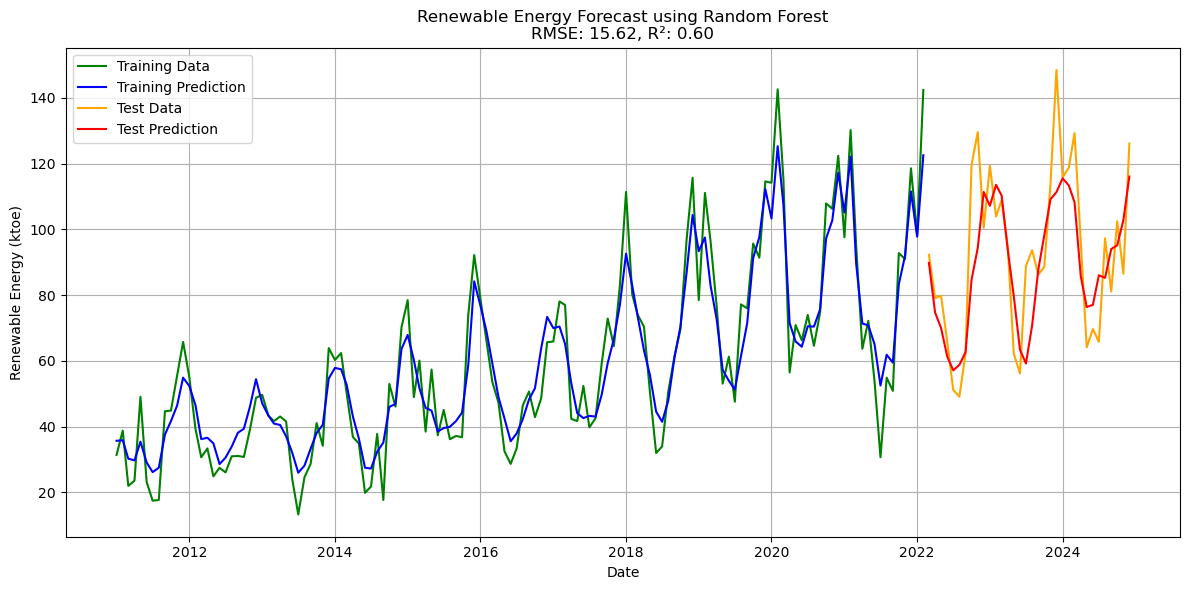

Model: XGBRegressor:
Best Params:{'colsample_bytree': 0.8, 'gamma': 0.3, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'random_state': 0, 'subsample': 0.8}
R2 score train: 0.9526, test: 0.5296.
Train MAE: 4.83231524282427, Test MAE: 12.4200029260972
Train MSE: 2.4888843706995423, Test RMSE: 16.960387526904647


Graph exported.


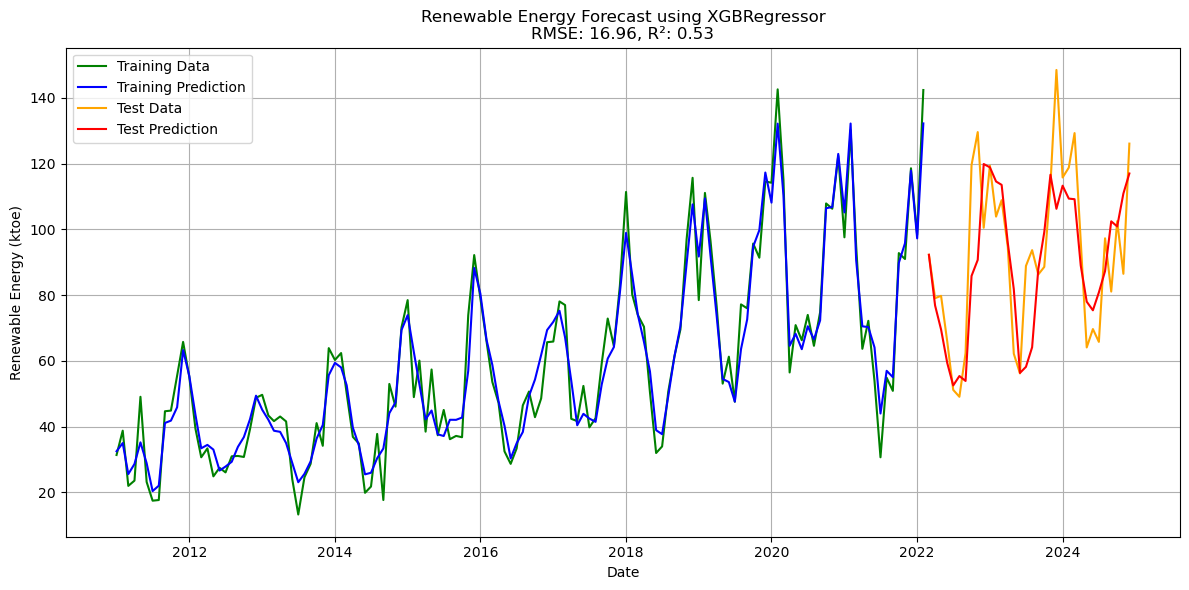

Runtime: 9.188 seconds.


In [131]:
# Start Timer
timer.start()

# Run automated training
R2, TreeBased_predictions = init_training(X, y, models, param_grid, 0.2, cv=3)

# Stop Timer
timer.stop()

    With the use of GridSearchCV, results show that both models exhibit strong performance on the training data, but perform poorly in the test data, with an R2 train score of 0.91 and a test score of 0.60 for the random forest, and a train and test score of 0.95, 0.52 for XGBoost, which indicates significant overfitting. Despite the hyperparameter tuning efforts, both models failed to generalize well to unseen data, concluding that these are not suitable for the study.

## 3.4 Results and Discussion 

Graph exported.


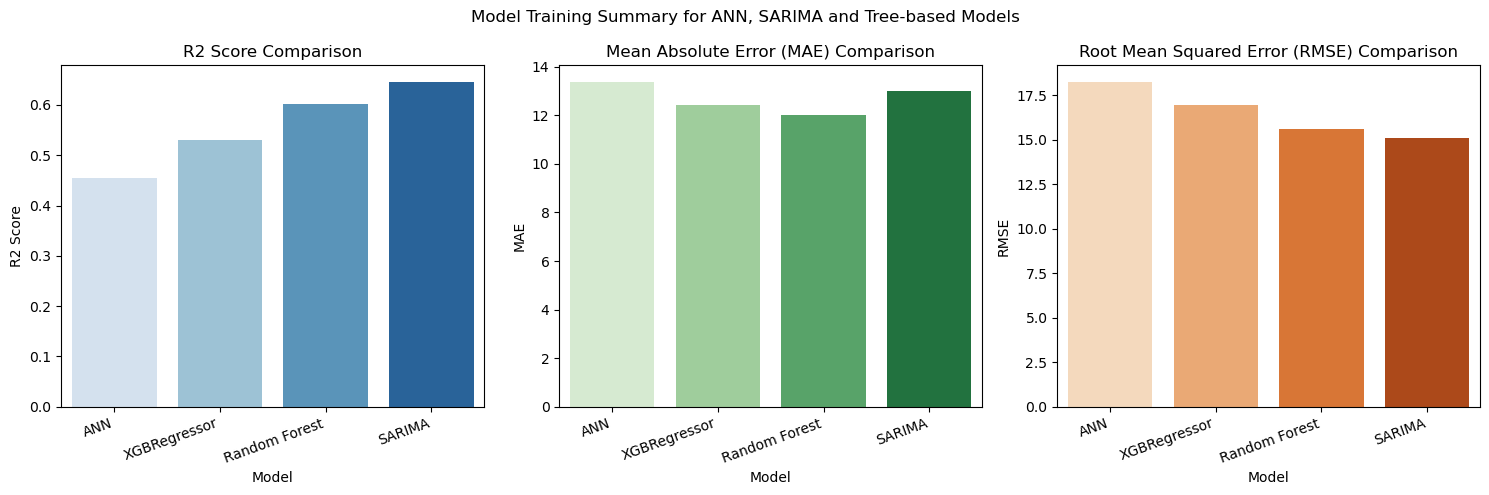

In [134]:
gen_model_training_summary(result=results, title='Model Training Summary for ANN, SARIMA and Tree-based Models')

    Based on the results, the ANN showed the weakest performance model among the models used, with a test R2 score of 0.42, scores also vary each execution, and it has the highest mean absolute error (MAE) and root mean square error (RMSE). Tree-based models, random forest, and XGBoost regressor outperform the other two models regarding MAE. However, the model generalized well in the training set, and underperformed in test set as there is a huge difference between the train and test R2 scores, with the train having 0.92 and the test 0.60 for Random Forest, and 0.95 with a test of 0.53 for XGBoost, which is a clear sign of overfitting as also observed in the graph above. Lastly, the SARIMA model reached an R2 score of  0.78 on training data and 0.65 on test data,  which suggests good generalisation in both the training and test data, and it has the lowest RMSE ( among the models. Thus, concluding that SARIMA is the best-suited algorithm for forecasting Ireland’s renewable energy production.

## <h2 style="text-align: center; font-family: Arial; font-weight:bold">References</h1>
<br />

Kruskal Test: <br />
Bhattacharjee, A. (2021) Kruskal-Wallis Test: A powerful tool for detecting seasonality in time series data using Python. Medium. Available at: https://medium.com/@avijit.bhattacharjee1996/kruskal-wallis-test-a-powerful-tool-for-detecting-seasonality-in-time-series-data-using-python-d827ef23d29e (Accessed: 7 May 2025).

Pearsons Test:<br />
SciPy, 2022. scipy.stats.pearsonr — SciPy v1.9.3 Manual. [online] Available at: https://docs.scipy.org/doc/scipy-1.9.3/reference/generated/scipy.stats.pearsonr.html [Accessed 8 May 2025].

Exporting Sarima Model: <br />
Bais, G., 2025. How to Save Trained Model in Python. Neptune.ai. Available at: https://neptune.ai/blog/saving-trained-model-in-python [Accessed 14 May 2025].

Decomposition:<br/>
Karve, A., 2020. Time Series Seasonal Decomposition. [online] Medium. Available at: https://medium.com/swlh/time-series-seasonal-decomposition-a300fe0f34dd [Accessed 16 May 2025].

### Dataset’s References and Licenses:

World Bank, 2023. Population, total – Ireland. [online] Available at: https://data.worldbank.org/indicator/SP.POP.TOTL?end=2023&locations=IE&start=2005 [Accessed 16 May 2025].
Licensed under the Creative Commons Attribution 4.0 International (CC BY 4.0). See: https://datacatalog.worldbank.org/public-licenses#cc-by.

Sustainable Energy Authority of Ireland (SEAI), 2024. Monthly Electricity Data – Customizable Download. [online] Available at: https://www.seai.ie/data-and-insights/seai-statistics/monthly-energy-data/electricity-monthly [Accessed 16 May 2025].

Anon, 2025. Final energy consumption. Available at: http://data.europa.eu/88u/dataset/97ilnrrfofyslunrcgklzq [Accessed May 16, 2025].
